# Notebook 1: PV-Wetterdaten Schweiz

Dieses Notebook lädt die PVOUT-Solardaten (Global Solar Atlas v2), prüft ihre Qualität,  
berechnet den mittleren PV-Ertrag pro Gemeinde und speichert das Ergebnis als CSV.  
Am Ende kann eine beliebige Schweizer Adresse eingegeben werden, um den PVOUT-Wert direkt abzulesen.

**PVOUT (PV Power Output)** = kWh pro kWp installierter Leistung und Jahr.  
Beispiel: PVOUT 1200 bedeutet, eine 5-kWp-Anlage produziert ca. 6000 kWh pro Jahr.


**swissBOUNDARIES3D.gpkg – die Gemeindegrenzen**
Herkunft: Bundesamt für Landestopografie swisstopo, offizieller Datensatz.
Enthält u.a. den Layer `tlm_hoheitsgebiet` mit den Polygonen aller Schweizer Gemeinden inkl. BFS-Nummer, Name und Kanton.


**Datenquelle:** Global Solar Atlas v2, World Bank Group  
https://globalsolaratlas.info/download/switzerland


## 0 Bibliotheken installieren

**Ziel:** Alle Python-Pakete laden, die in diesem Notebook benötigt werden.

**Vorgehen:** Alle benötigten Pakete werden installiert, falls sie noch nicht vorhanden sind.

**Bibliotheken und ihre Aufgaben in diesem Notebook:**

| Bibliothek | Wird verwendet in | Aufgabe |
|---|
| `rasterio` | Schritte 3, 5, 13 | Öffnet `.tif`-Dateien, liest Pixelwerte, rechnet geografische Koordinaten in Pixelpositionen um |
| `numpy` | Schritt 3 | Statistische Auswertung der Pixelwerte (Min, Max, Mittelwert) |
| `geopandas` | Schritte 6, 13 | Lädt Gemeindegrenzen, rechnet Koordinatensysteme um, ordnet Punkte Gemeindepolygonen zu |
| `rasterstats` | Schritt 7 | Berechnet für jedes Gemeindepolygon den Mittelwert aller darin liegenden PVOUT-Pixel |
| `fiona` | Schritt 6 | Treiber zum Öffnen von `.gpkg`-Dateien (wird von geopandas intern als Engine genutzt) |
| `matplotlib` | Schritte 4, 10 | Erstellt Karten und Heatmaps |
| `requests` | Schritt 13 | Sendet HTTP-Anfrage an die swisstopo Geocoding-API |
| `geopy` | Schritt 13 | Geocoding-Fallback: wandelt Adressen in Koordinaten um (Nominatim/OpenStreetMap) |
| `glob`, `os`, `shutil`, `zipfile` | Schritt 2 | Dateien finden, kopieren und entpacken |

In [ ]:
import geopandas as gpd

# Definieren der Pfade zu den Quelldateien
# Diese URLs zeigen auf die Rohdaten im GitHub-Repository.
PVOUT_PATH = 'https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/PVOUT.tif'
GPKG_PATH  = 'https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg'

print(f'PVOUT.tif path: {PVOUT_PATH}')
print(f'GPKG path:      {GPKG_PATH}')
print("-" * 50) # Trennzeichen zur besseren Lesbarkeit

# Laden und Inspizieren der GPKG-Datei
# Verwende die definierte GitHub Raw URL für die GPKG-Datei.
raw_github_url = GPKG_PATH

print(f"Versuche Datei von: {raw_github_url} zu lesen")

try:
    # Verwende geopandas, um die GPKG-Datei zu öffnen.
    gdf = gpd.read_file(raw_github_url)
    print(f"Erfolgreich geöffnet: {raw_github_url}")

    print("\n--- GeoDataFrame Information ---")
    print(f"Anzahl der Features (Zeilen): {len(gdf)}")
    print(f"Koordinatenreferenzsystem (CRS): {gdf.crs}")
    print(f"Verfügbare Spalten: {list(gdf.columns)}")
    print("\nErste 5 Zeilen der Daten:")
    print(gdf.head())

except Exception as e:
    print(f"Fehler beim Lesen der Datei: {e}")
    print("Bitte stellen Sie sicher, dass die URL auf eine Rohdatei zeigt und zugänglich ist.")

PVOUT.tif path: https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/PVOUT.tif
GPKG path:      https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg
--------------------------------------------------
Attempting to read file from: https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg
Successfully opened: https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg

--- GeoDataFrame Information ---
Number of features (rows): 6659
Coordinate Reference System (CRS): EPSG:2056
Columns available: ['uuid', 'datum_aenderung', 'datum_erstellung', 'erstellung_jahr', 'erstellung_monat', 'grund_aenderung', 'herkunft', 'herkunft_jahr', 'herkunft_monat', 'revision_jahr', 'revision_monat', 'revision_qualitaet', 'objektart', 'icc', 'typ', 'geometry']

First 5 rows of the data:
                                     uuid datum_aenderung datum_ers

In [ ]:
!pip install rasterio geopandas rasterstats fiona geopy --quiet

## 1 Metadaten der PVOUT-Datei prüfen (Qualitätskontrolle 1a)

**Ziel:** Sicherstellen, dass die richtige Datei geladen wurde und die Werte plausibel sind.

**Vorgehen:** Koordinatensystem, Auflösung und Wertebereich automatisch prüfen. Jeder Check gibt ✓ (bestanden) oder ✗ (Problem) aus.

**Was der Code macht – im Detail:**

1. `rasterio.open(PVOUT_PATH)` öffnet die .tif-Datei und liest ihre Metadaten (Koordinatensystem, Auflösung, geografische Ausdehnung)
2. `src.read(1, masked=True)` lädt alle Pixelwerte als «Masked Array». Pixel ausserhalb der Schweiz haben keinen gültigen Wert (Nodata) und werden maskiert (ausgeblendet)
3. `data.compressed()` entfernt alle maskierten Pixel – nur gültige Schweizer Werte bleiben übrig. Ohne diesen Schritt würde `.min()` / `.max()` NaN zurückgeben

**Wie führen wir den Plausibilitätschecks durch?**

| Check | Erwarteter Wert | Warum genau dieser Bereich |
|---|
| CRS = EPSG:4326 | WGS84 (GPS-Koordinaten in Grad) | Alle anderen Schritte rechnen mit Längen-/Breitengrad. Ein anderes CRS würde die gesamte Koordinatenlogik zum Scheitern bringen |
| Auflösung ~1 km | 0.005°–0.02° | Die Datei hat laut Metadaten ~0.0083° ≈ 1 km pro Pixel. Der Check prüft nur, ob wir uns in der richtigen Grössenordnung befinden – nicht zu grob (>20 km) und nicht zu fein (<500 m) |
| Min > 500 | kWh/kWp/Jahr | Physikalische Untergrenze – selbst im schattigsten Schweizer Tal ist PVOUT höher. Werte unter 500 würden auf eine falsche Datei hinweisen (z.B. Temperaturdaten in °C) |
| Max < 2000 | kWh/kWp/Jahr | Physikalische Obergrenze für die Schweiz. Sonnigste Orte wie Wallis/Tessin erreichen ca. 1490 kWh/kWp/Jahr |
| Mittelwert 1000–1400 | kWh/kWp/Jahr | Schweizer Durchschnitt. Zu hohe oder zu tiefe Werte deuten auf eine andere Region oder ein anderes Datenprodukt hin |

In [ ]:
import rasterio
import numpy as np

with rasterio.open(PVOUT_PATH) as src:
    crs       = src.crs
    aufl      = src.res
    bounds    = src.bounds
    transform = src.transform
    data      = src.read(1)  # reguläres numpy-Array; Nodata-Pixel haben Wert NaN

# ~np.isnan(data) = True für alle gültigen Pixel (Schweiz), False für NaN-Pixel (Ausland)
gueltige_werte = data[~np.isnan(data)]

print(f'Koordinatensystem : {crs}')
print(f'Auflösung         : {aufl[0]:.4f}° x {aufl[1]:.4f}° (ca. {aufl[0]*111:.1f} km x {aufl[1]*111:.1f} km)')
print(f'Bounding Box      : {bounds.left:.2f}°E – {bounds.right:.2f}°E, {bounds.bottom:.2f}°N – {bounds.top:.2f}°N')
print(f'Gültige Pixel     : {len(gueltige_werte):,}')
print(f'Wertebereich      : {gueltige_werte.min():.0f} – {gueltige_werte.max():.0f} kWh/kWp/Jahr')
print(f'Mittelwert        : {gueltige_werte.mean():.0f} kWh/kWp/Jahr')
print()

checks = [
    ('CRS = WGS84 (EPSG:4326)',          'EPSG:4326' in str(crs)),
    ('Auflösung ~1 km (0.005°–0.02°)',   0.005 < aufl[0] < 0.02),
    ('Min > 500 kWh/kWp/Jahr',           float(gueltige_werte.min()) > 500),
    ('Max < 2000 kWh/kWp/Jahr',          float(gueltige_werte.max()) < 2000),
    ('Mittelwert 1000–1400',             1000 < float(gueltige_werte.mean()) < 1400),
]
for name, ok in checks:
    symbol = '✓' if ok else '✗'
    print(f'  {symbol} {name}')

Koordinatensystem : EPSG:4326
Auflösung         : 0.0083° x 0.0083° (ca. 0.9 km x 0.9 km)
Bounding Box      : 5.00°E – 11.00°E, 45.00°N – 48.00°N
Gültige Pixel     : 94,134
Wertebereich      : 603 – 1616 kWh/kWp/Jahr
Mittelwert        : 1231 kWh/kWp/Jahr

  ✓ CRS = WGS84 (EPSG:4326)
  ✓ Auflösung ~1 km (0.005°–0.02°)
  ✓ Min > 500 kWh/kWp/Jahr
  ✓ Max < 2000 kWh/kWp/Jahr
  ✓ Mittelwert 1000–1400


## 2 Pixel-Tabelle erstellen (Qualitätskontrolle 1b)

**Ziel:** Alle gültigen Pixel mit ihren Koordinaten in eine Tabelle laden, um die Daten direkt nachschlagen und verifizieren zu können.

**Vorgehen:** Aus dem Raster werden für jeden gültigen Pixel Breitengrad, Längengrad und PVOUT-Wert berechnet.

**Was der Code macht:**
- `np.where(~np.isnan(data))` liefert die Zeilen- und Spaltenindizes aller Nicht-NaN-Pixel
- `rasterio.transform.xy(transform, rows, cols)` rechnet diese Indizes in geografische Koordinaten um
- Das Ergebnis ist eine Tabelle mit ca. 7000 Einträgen – jeder Pixel der Schweiz mit seinen genauen Koordinaten

**Wie kann man die Daten nachschlagen?**  
Die Koordinaten in der Tabelle (lat/lon) können direkt in Google Maps oder map.geo.admin.ch eingegeben werden, um zu prüfen ob der Ort und der PVOUT-Wert plausibel sind.

In [ ]:
import pandas as pd

# Indizes aller gültigen Pixel (kein NaN)
pixel_rows, pixel_cols = np.where(~np.isnan(data))

# Pixelindizes → geografische Koordinaten
pixel_lons, pixel_lats = rasterio.transform.xy(transform, pixel_rows, pixel_cols)

# DataFrame mit allen Pixeln
pixel_df = pd.DataFrame({
    'lat':               pixel_lats,
    'lon':               pixel_lons,
    'pvout_kwh_kwp_year': data[pixel_rows, pixel_cols]
}).round({'lat': 4, 'lon': 4, 'pvout_kwh_kwp_year': 1})

print(f'Pixel total: {len(pixel_df):,}')
print()

print('Top 10 – sonnigste Pixel:')
print(pixel_df.nlargest(10, 'pvout_kwh_kwp_year').to_string(index=False))

print()
print('Bottom 10 – schattigste Pixel:')
print(pixel_df.nsmallest(10, 'pvout_kwh_kwp_year').to_string(index=False))

print()
print('Tipp: lat/lon in https://map.geo.admin.ch eingeben und PVOUT-Wert visuell prüfen')

Pixel total: 94,134

Top 10 – sonnigste Pixel:
    lat    lon  pvout_kwh_kwp_year
45.9875 7.5792         1616.199951
46.0542 7.8708         1613.300049
46.0542 7.8792         1609.300049
46.0458 7.8792         1606.400024
45.8875 7.2542         1605.599976
45.8625 7.3542         1600.199951
45.9208 7.7292         1599.800049
45.8542 7.3542         1599.099976
45.9708 7.4042         1598.699951
45.9792 7.4375         1597.599976

Bottom 10 – schattigste Pixel:
    lat    lon  pvout_kwh_kwp_year
47.0125 8.9708          603.400024
47.0125 8.9625          618.000000
47.0208 8.9958          637.400024
47.0125 9.0125          641.000000
47.0125 8.9792          645.400024
46.6208 8.0708          656.400024
46.8125 8.7625          659.599976
46.3625 6.7958          660.000000
46.8125 8.7542          661.500000
47.0208 9.0042          665.500000

Tipp: lat/lon in https://map.geo.admin.ch eingeben und PVOUT-Wert visuell prüfen


## 3 PVOUT-Karte der Schweiz anzeigen (Qualitätskontrolle 2)

**Ziel:** Sichtprüfung – Süden (Tessin und Wallis) muss deutlich dunkler/röter erscheinen als der Norden.

**Vorgehen:** Heatmap mit Farbskala anzeigen.

**Was der Code macht:**
- `imshow` zeigt das Raster als Bild – jeder Pixel erhält eine Farbe basierend auf seinem PVOUT-Wert
- `YlOrRd` = Farbpalette von Gelb (niedrig) über Orange bis Rot (hoch)
- `vmin=900, vmax=1500` legt die Farbskala fest, sodass die Unterschiede gut sichtbar sind
- Die Farbskala rechts erklärt die Bedeutung der Farben in kWh/kWp/Jahr

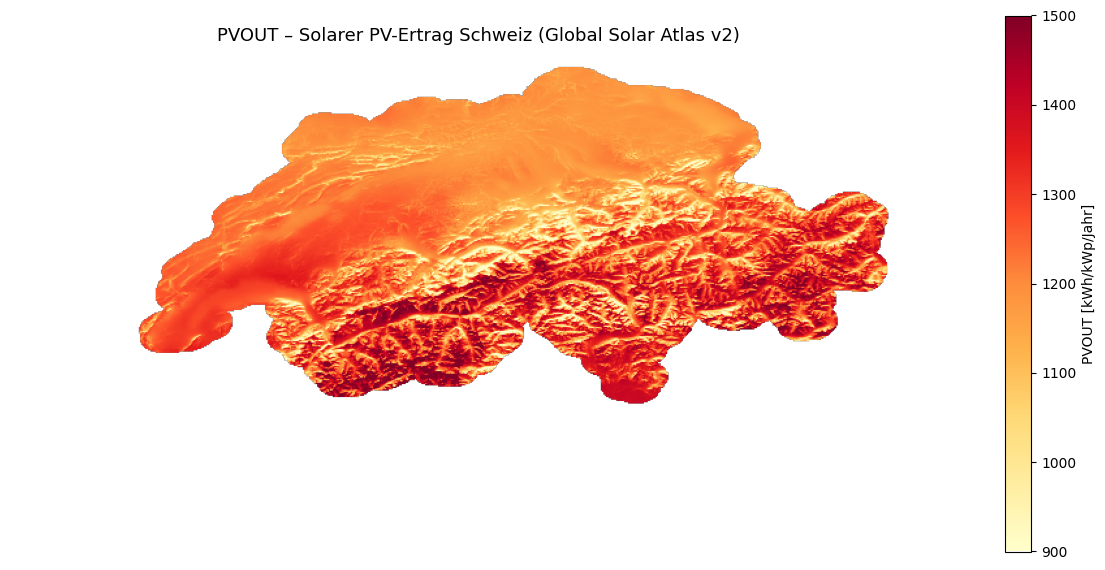

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
im = plt.imshow(data, cmap='YlOrRd', vmin=900, vmax=1500)
plt.colorbar(im, label='PVOUT [kWh/kWp/Jahr]', shrink=0.8)
plt.title('PVOUT – Solarer PV-Ertrag Schweiz (Global Solar Atlas v2)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

##4 Werte an bekannten Orten prüfen (Qualitätskontrolle 3)

**Ziel:** Die Rangfolge Lugano > Bern > Basel muss stimmen. Wenn das nicht der Fall ist, wurde vermutlich die falsche Datei geladen.

**Vorgehen:** PVOUT-Pixelwert an drei bekannten Koordinaten ablesen und mit Erwartungswerten vergleichen. Die drei Orte wurden bewusst weit voneinander gewählt, damit der Unterschied auch bei der ~1 km Auflösung klar messbar ist.

**Was der Code macht:**
- `rowcol(transform, lon, lat)` berechnet den Zeilen-/Spalten-Index im Raster für eine geographische Koordinate (Längen- und Breitengrad)
- `src.read(1)[r, c]` liest den Pixelwert an dieser Stelle direkt aus dem Daten-Array
- Am Ende wird automatisch geprüft, ob die Süd-nach-Nord-Rangfolge stimmt

In [ ]:
from rasterio.transform import rowcol

prueforte = [
    ('Lugano', 8.96, 46.00, '~1450 – Tessin, sonnigste Grossstadt CH'),
    ('Bern',   7.45, 46.95, '~1150 – Mittelland'),
    ('Basel',  7.59, 47.56, '~1050 – nördlichste Grossstadt'),
]

with rasterio.open(PVOUT_PATH) as src:
    print('{:<10} {:>22}  {}'.format('Ort', 'PVOUT [kWh/kWp/Jahr]', 'Erwartung'))
    print('-' * 65)
    werte = []
    for name, lon, lat, erwartung in prueforte:
        r, c = rowcol(src.transform, lon, lat)
        val = float(src.read(1)[r, c])
        werte.append(val)
        print('{:<10} {:>22.0f}  {}'.format(name, val, erwartung))

rangfolge_ok = all(werte[i] >= werte[i+1] for i in range(len(werte)-1))
print()
if rangfolge_ok:
    print('✓ Rangfolge korrekt (Süd > Nord) – Daten plausibel')
else:
    print('✗ Rangfolge stimmt nicht – Datei prüfen!')

Ort          PVOUT [kWh/kWp/Jahr]  Erwartung
-----------------------------------------------------------------
Lugano                       1367  ~1450 – Tessin, sonnigste Grossstadt CH
Bern                         1258  ~1150 – Mittelland
Basel                        1199  ~1050 – nördlichste Grossstadt

✓ Rangfolge korrekt (Süd > Nord) – Daten plausibel


##5 Gemeindegrenzen der Schweiz laden

**Ziel:** Polygone aller Schweizer Gemeinden laden, damit der PVOUT-Wert pro Gemeinde berechnet werden kann.

**Vorgehen:** Die swissBOUNDARIES3D-Datei (von swisstopo) enthält die offiziellen Gemeindegrenzen. Wir laden den Layer `tlm_hoheitsgebiet`.

**Was der Code macht:**
- Das GPKG wird von der GitHub Raw URL heruntergeladen und auf den lokalen `/content/`-Speicher kopiert. Das ist notwendig, weil `geopandas` `.gpkg`-Dateien nicht direkt von einer URL öffnen kann.
- `engine='fiona'` gibt den korrekten Treiber zum Öffnen von GPKG-Dateien an.
- `to_crs('EPSG:4326')` konvertiert das Koordinatensystem: von Schweizer LV95 (EPSG:2056) zu WGS84 (EPSG:4326) – dem gleichen System wie PVOUT.tif

**Manuelle Plausibilitätsprüfung:**
Die Tabelle zeigt BFS-Nummer, Gemeindename und Kantonnummer. Diese kann mit der offiziellen swisstopo-Übersichtskarte abgeglichen werden:
https://www.swisstopo.admin.ch/de/ubersichtskarten-der-schweiz
Beispiel: BFS-Nr. 261 = Zürich, BFS-Nr. 6621 = Lugano – stimmt das überein?

In [ ]:
import geopandas as gpd

# Lade die Gemeindegrenzen direkt aus der GitHub URL
gemeinden_geo  = gpd.read_file(GPKG_PATH, layer='tlm_hoheitsgebiet', engine='fiona')
gemeinden_wgs84 = gemeinden_geo.to_crs('EPSG:4326')

print(f'Gemeinden geladen : {len(gemeinden_wgs84)}')
print(f'Koordinatensystem : {gemeinden_wgs84.crs}')
gemeinden_wgs84[['bfs_nummer', 'name', 'kantonsnummer']].head(3)

Gemeinden geladen : 2136
Koordinatensystem : EPSG:4326


,bfs_nummer,name,kantonsnummer
0,131,Adliswil,1.0
1,3714,Rheinwald,18.0
2,5722,Grens,22.0


In [ ]:
# Definiere das KANTON_NAME-Wörterbuch einmal zur Verwendung im gesamten Notebook
KANTON_NAME = {
    1: 'Zürich',
    2: 'Bern',
    3: 'Luzern',
    4: 'Uri',
    5: 'Schwyz',
    6: 'Obwalden',
    7: 'Nidwalden',
    8: 'Glarus',
    9: 'Zug',
    10: 'Fribourg',
    11: 'Solothurn',
    12: 'Basel-Stadt',
    13: 'Basel-Landschaft',
    14: 'Schaffhausen',
    15: 'Appenzell Ausserrhoden',
    16: 'Appenzell Innerrhoden',
    17: 'St. Gallen',
    18: 'Graubünden',
    19: 'Aargau',
    20: 'Thurgau',
    21: 'Ticino',
    22: 'Vaud',
    23: 'Valais',
    24: 'Neuchâtel',
    25: 'Genève',
    26: 'Jura',
}

##6 Mittleren PVOUT pro Gemeinde berechnen (Zonale Statistik)

**Ziel:** Für jede der rund 2136 Schweizer Gemeinden den durchschnittlichen PVOUT-Wert berechnen.

**Vorgehen:** Das PVOUT-Raster und die Gemeindegrenzen werden übereinandergelegt. Für jede Gemeinde werden alle darin liegenden Pixel gemittelt.

**Was der Code macht:**
- `zonal_stats()` überlagert Gemeinde-Polygone mit dem PVOUT-Raster
- Für jede Gemeinde werden alle Pixel innerhalb des Polygons gemittelt (`stats=['mean']`)
- `nodata=-9999` teilt dem Algorithmus mit, welcher Wert für «keine Daten» steht
- **Dieser Schritt dauert 1–3 Minuten** – das ist normal bei über 2000 Gemeinden

**Quercheck der Ergebnisse:**  
Das Bundesamt für Statistik (BFS) veröffentlicht Daten zu allen Schweizer Gemeinden:  
https://www.bfs.admin.ch/bfs/en/home/news/whats-new.assetdetail.36390081.html  
Damit lassen sich Gemeindename, BFS-Nummer und Kanton gegenseitig validieren – ein guter Anhaltspunkt, ob die Daten vollständig und korrekt zugeordnet wurden.

In [ ]:
from rasterstats import zonal_stats

print('Berechne mittleren PVOUT pro Gemeinde')
stats = zonal_stats(
    gemeinden_wgs84,
    PVOUT_PATH,
    stats=['mean'],
    nodata=-9999
)
print(f'✓ Fertig: {len(stats)} Gemeinden verarbeitet')

Berechne mittleren PVOUT pro Gemeinde
✓ Fertig: 2136 Gemeinden verarbeitet


### PVOut_mean mit NaN-Daten

Bei 4 Gemeinden konnte kein mittlerer PVOUT-Wert berechnet werden. Ohne all_touched=True (Standardverhalten): Die Funktion berücksichtigt nur die Rasterpixel, deren Zentrum innerhalb des Gemeindepolygons liegt. Wenn ein Polygon sehr klein ist oder eine sehr schmale, unregelmässige Form hat, kann es vorkommen, dass kein einziges Pixelzentrum darin liegt. In solchen Fällen würde der pvout_mean für diese Gemeinde None (keine Daten) ergeben.

In [ ]:
nodata_count = sum(1 for s in stats if s['mean'] is None)

if nodata_count > 0:
    print(f'Es wurden {nodata_count} Gemeinden mit nodata=-9999 (repräsentiert als None) gefunden.')
else:
    print('Es wurden keine Gemeinden mit nodata=-9999 gefunden (alle Gemeinden hatten PVOUT-Werte).')


Es wurden 4 Gemeinden mit nodata=-9999 (repräsentiert als None) gefunden.


**Gottlieben (TG)**: eine der flächenmässig kleinsten Gemeinden der Schweiz, nur ca. 0,27 km². Bei 250 m Pixelgrösse ist das praktisch ein einziger Pixel breit, wenn dessen Zentrum knapp ausserhalb liegt, gibt's nichts zu mitteln.

**Wiliberg (AG)**: ca. 1,5 km², langgezogene Form auf einem Hügelrücken. Auch hier kann der Pixelraster die schmale Geometrie verfehlen.

**Gravesano (TI)**: ca. 1,4 km², ähnliches Problem.

**Comunanza Capriasca/Lugano**: das ist ein Sonderfall: keine reguläre Gemeinde, sondern eine Comunanza (gemeinschaftlich genutztes Gebiet zwischen Tessiner Gemeinden, oft Alpgebiet). Diese haben oft sehr unregelmässige Geometrien und tauchen im swisstopo-Datensatz mit eigener BFS-Nummer auf, obwohl sie politisch keine eigene Gemeinde sind.

In [ ]:
import pandas as pd

# Definition des KANTON_NAME Dictionaries, um Kantonsnummern den Kantonsnamen zuzuordnen
KANTON_NAME = {
    1: 'Zürich',
    2: 'Bern',
    3: 'Luzern',
    4: 'Uri',
    5: 'Schwyz',
    6: 'Obwalden',
    7: 'Nidwalden',
    8: 'Glarus',
    9: 'Zug',
    10: 'Fribourg',
    11: 'Solothurn',
    12: 'Basel-Stadt',
    13: 'Basel-Landschaft',
    14: 'Schaffhausen',
    15: 'Appenzell Ausserrhoden',
    16: 'Appenzell Innerrhoden',
    17: 'St. Gallen',
    18: 'Graubünden',
    19: 'Aargau',
    20: 'Thurgau',
    21: 'Ticino',
    22: 'Vaud',
    23: 'Valais',
    24: 'Neuchâtel',
    25: 'Genève',
    26: 'Jura',
}

stats_df = pd.DataFrame(stats)

# Füge die PVOUT-Werte (mean) den Gemeinden wieder hinzu
gemeinden_wgs84_with_stats = gemeinden_wgs84.copy()
gemeinden_wgs84_with_stats['pvout_mean'] = stats_df['mean']

# Füge den Kantonsnamen hinzu
gemeinden_wgs84_with_stats['kanton_name'] = gemeinden_wgs84_with_stats['kantonsnummer'].map(KANTON_NAME)

# Filtere die Gemeinden, bei denen der PVOUT-Mittelwert None ist
missing_pvout_gemeinden = gemeinden_wgs84_with_stats[gemeinden_wgs84_with_stats['pvout_mean'].isna()]

print('Details der Gemeinden mit fehlenden PVOUT-Werten:')
display(missing_pvout_gemeinden[['bfs_nummer', 'name', 'kanton_name', 'pvout_mean']])

Details der Gemeinden mit fehlenden PVOUT-Werten:


,bfs_nummer,name,kanton_name,pvout_mean
333,4651,Gottlieben,Thurgau,NaN
1008,4288,Wiliberg,Aargau,NaN
1275,5187,Gravesano,Ticino,NaN
1442,5394,Comunanza Capriasca/Lugano,Ticino,NaN


In [ ]:
import rasterio
from rasterio.features import rasterize
import numpy as np
import geopandas as gpd

# 'missing_pvout_gemeinden' und 'PVOUT_PATH' sind bereits im Notebook definiert.
# 'aufl' (Auflösung) ist ebenfalls definiert.

pixel_counts = {}

print("Berechne die Anzahl der durch die Gemeinden abgedeckten Pixel...")

with rasterio.open(PVOUT_PATH) as src:
    # Iteriere durch jede der Gemeinden mit fehlenden PVOUT-Werten
    for index, row in missing_pvout_gemeinden.iterrows():
        municipality_name = row['name']
        geometry = row.geometry

        # Erstelle ein binäres Raster, bei dem Pixel, die von der Geometrie abgedeckt sind, den Wert 1 haben, andere 0.
        # 'out_shape' und 'transform' müssen mit dem PVOUT-Raster übereinstimmen.
        # 'all_touched=True' stellt sicher, dass alle Pixel gezählt werden, die die Geometrie berühren (auch nur teilweise).
        mask = rasterize(
            [(geometry, 1)], # Geometrie und ein Wert zum 'Brennen'
            out_shape=src.shape,
            transform=src.transform,
            fill=0, # Wert für Bereiche, die nicht von der Geometrie abgedeckt werden
            all_touched=True # Beziehe alle Pixel mit ein, die die Geometrie berühren
        )

        # Zähle die Anzahl der Pixel, die Teil der Gemeinde sind (Wert 1)
        num_pixels = np.sum(mask == 1)
        pixel_counts[municipality_name] = num_pixels

print("\nAnzahl der durch die Gemeinden abgedeckten Pixel (unabhängig von PVOUT-Werten):")
for name, count in pixel_counts.items():
    print(f"- {name}: {count} Pixel")

# Zeige auch die ungefähre Fläche eines Pixels an, falls 'aufl' definiert ist
if 'aufl' in locals() or 'aufl' in globals():
    print(f"\nEin Pixel hat eine ungefähre Fläche von {aufl[0]*111:.1f} km x {aufl[1]*111:.1f} km, also ca. {(aufl[0]*111) * (aufl[1]*111):.1f} km².")
else:
    print("\nDie Auflösung des Rasters (Variable 'aufl') ist nicht verfügbar, um die Pixelgröße zu berechnen.")

Berechne die Anzahl der durch die Gemeinden abgedeckten Pixel...

Anzahl der durch die Gemeinden abgedeckten Pixel (unabhängig von PVOUT-Werten):
- Gottlieben: 4 Pixel
- Wiliberg: 8 Pixel
- Gravesano: 6 Pixel
- Comunanza Capriasca/Lugano: 2 Pixel

Ein Pixel hat eine ungefähre Fläche von 0.9 km x 0.9 km, also ca. 0.9 km².


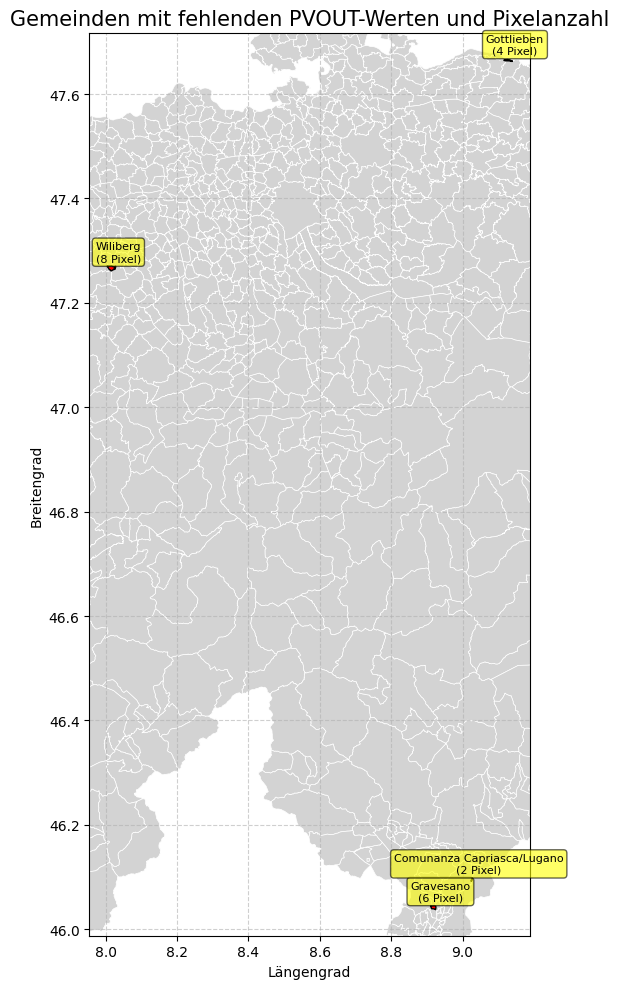

In [ ]:
import matplotlib.pyplot as plt

# Berechne die Bounding Box der fehlenden Gemeinden für den Zoom
minx, miny, maxx, maxy = missing_pvout_gemeinden.total_bounds

# Füge einen Puffer zur Bounding Box hinzu für eine bessere Visualisierung
buffer = 0.05 # Grad

fig, ax = plt.subplots(figsize=(10, 10))

# Plotte alle Gemeinden im Hintergrund
gemeinden_wgs84.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5)

# Plotte die Gemeinden mit fehlenden PVOUT-Werten in einer deutlichen Farbe (z.B. rot)
missing_pvout_gemeinden.plot(ax=ax, color='red', edgecolor='black', linewidth=1)

# Füge Text-Annotations für jede Gemeinde hinzu, die den Namen und die Pixelanzahl anzeigen
for idx, row in missing_pvout_gemeinden.iterrows():
    name = row['name']
    count = pixel_counts.get(name, 'N/A') # Hol die Pixelzahl aus dem zuvor berechneten Dictionary
    centroid = row.geometry.centroid
    ax.annotate(
        f"{name}\n({count} Pixel)",
        xy=(centroid.x, centroid.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color='black',
        ha='center',
        bbox=dict(boxstyle="round,pad=0.3", fc='yellow', alpha=0.6)
    )

# Setze Titel und Beschriftungen
ax.set_title('Gemeinden mit fehlenden PVOUT-Werten und Pixelanzahl', fontsize=15)
ax.set_xlabel('Längengrad')
ax.set_ylabel('Breitengrad')

# Setze die Grenzen der Karte, um auf die fehlenden Gemeinden zu zoomen
ax.set_xlim(minx - buffer, maxx + buffer)
ax.set_ylim(miny - buffer, maxy + buffer)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

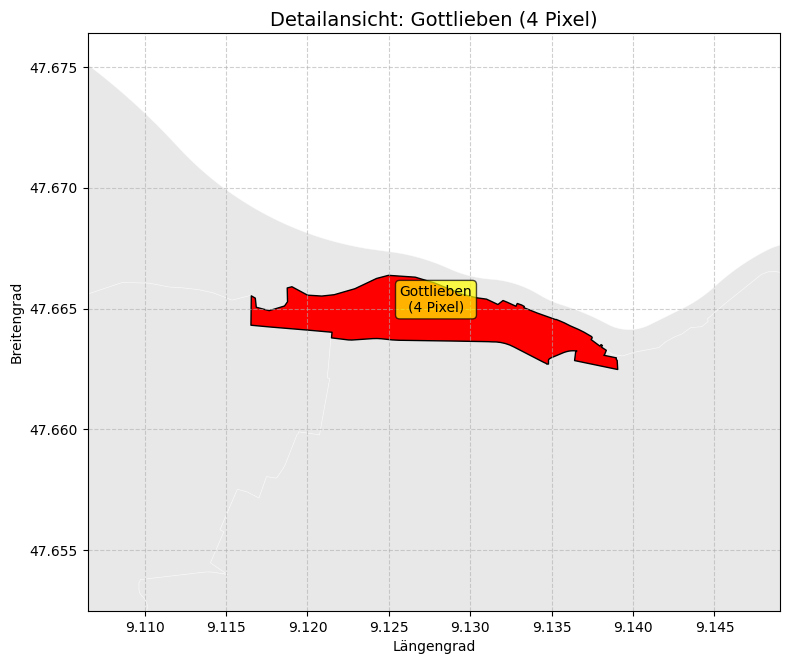

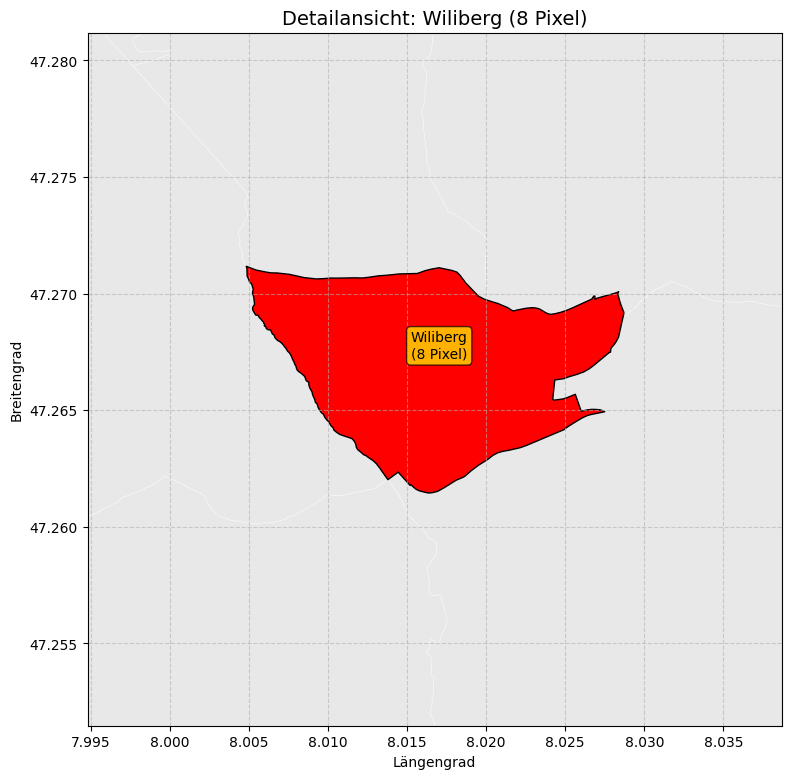

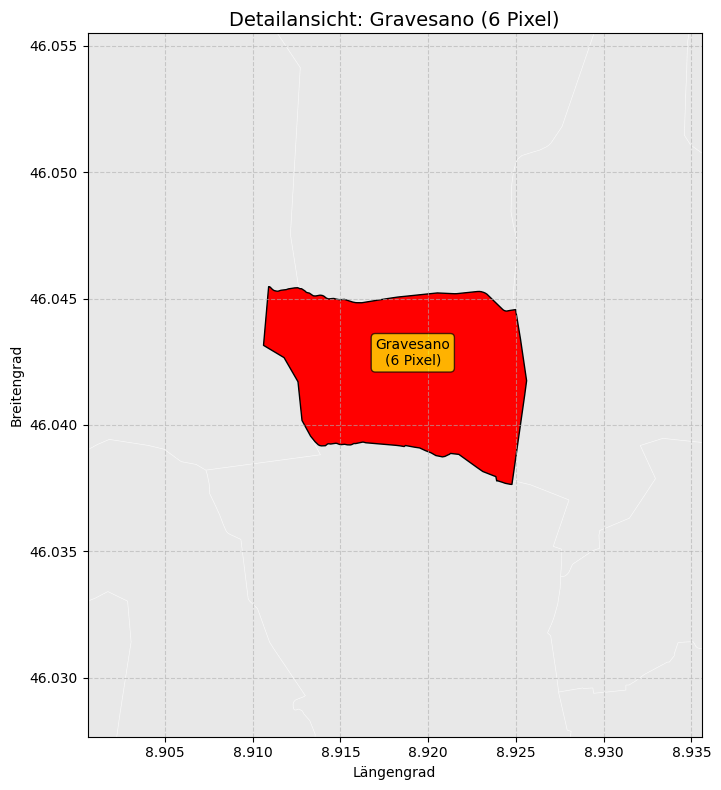

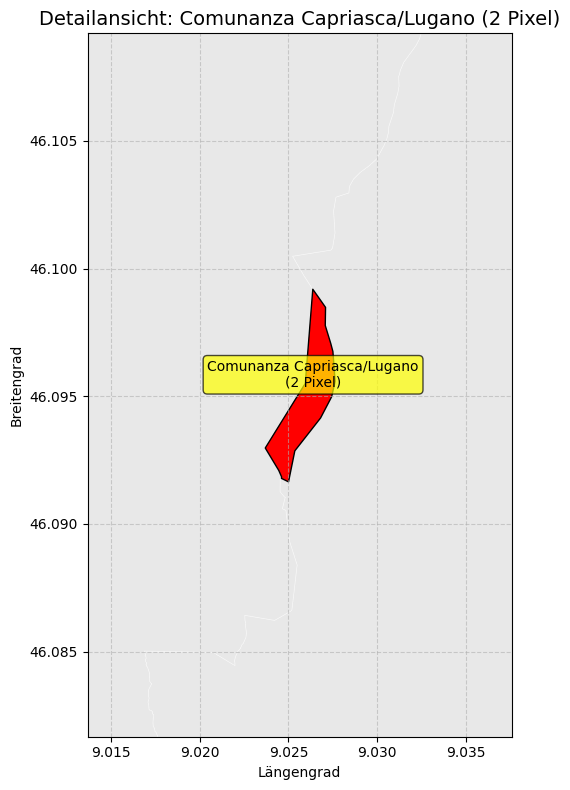

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Iteriere durch jede einzelne Gemeinde mit fehlenden PVOUT-Werten
for idx, row in missing_pvout_gemeinden.iterrows():
    municipality_name = row['name']
    current_municipality = gpd.GeoDataFrame([row], crs=missing_pvout_gemeinden.crs)

    # Berechne die Bounding Box für die aktuelle Gemeinde für einen engen Zoom
    minx, miny, maxx, maxy = current_municipality.total_bounds

    # Füge einen kleinen Puffer hinzu
    buffer_factor = 0.01  # Kleinere Puffer für engeren Zoom
    minx -= buffer_factor
    miny -= buffer_factor
    maxx += buffer_factor
    maxy += buffer_factor

    fig, ax = plt.subplots(figsize=(8, 8))

    # Plotte alle Gemeinden im Hintergrund, um Kontext zu geben
    gemeinden_wgs84.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5, alpha=0.5)

    # Plotte die aktuelle Gemeinde in einer deutlichen Farbe
    current_municipality.plot(ax=ax, color='red', edgecolor='black', linewidth=1)

    # Füge Text-Annotation für den Namen und die Pixelanzahl hinzu
    count = pixel_counts.get(municipality_name, 'N/A')
    centroid = row.geometry.centroid
    ax.annotate(
        f"{municipality_name}\n({count} Pixel)",
        xy=(centroid.x, centroid.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
        color='black',
        ha='center',
        bbox=dict(boxstyle="round,pad=0.3", fc='yellow', alpha=0.7)
    )

    # Setze Titel und Beschriftungen
    ax.set_title(f'Detailansicht: {municipality_name} ({count} Pixel)', fontsize=14)
    ax.set_xlabel('Längengrad')
    ax.set_ylabel('Breitengrad')

    # Setze die Grenzen der Karte für den engen Zoom
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Die vier Gemeinden enthalten NaN-Daten, da sie eine sehr kleine Fläche, sehr unregelmässige Form oder Sonderfälle wie "Comunanza" sind. Selbst all_touched=True hat keine Werte geliefert. Das deutet darauf hin, dass die Geometrie dieser Gemeinden so extrem ist, dass selbst eine grosszügigere Pixelzuweisung keine gültigen PVOUT-Daten in den 1x1 km-Rastern findet.

In [ ]:
# Dieser Code-Abschnitt prüft, ob die 4 Gemeinden mit fehlenden PVOUT-Werten auch dann noch NaN-Werte aufweisen, wenn die zonal_stats-Berechnung mit dem Parameter 'all_touched=True' durchgeführt wird. Dies dient der Verifizierung, ob die extremen Geometrien oder geringe Flächen die Ursache für die fehlenden Daten sind.
from rasterstats import zonal_stats
import pandas as pd
print('Berechne mittleren PVOUT für die 4 ehemals fehlenden Gemeinden mit all_touched=True...')
# Filtere die 4 Gemeinden, die zuvor fehlende PVOUT-Werte hatten
municipalities_to_recheck = gemeinden_wgs84[gemeinden_wgs84['bfs_nummer'].isin(missing_pvout_gemeinden['bfs_nummer'])]
# Führe zonal_stats nur für diese Gemeinden mit all_touched=True aus
stats_all_touched = zonal_stats(
    municipalities_to_recheck,
    PVOUT_PATH,
    stats=['mean'],
    nodata=-9999,
    all_touched=True
)
# Erstelle ein DataFrame aus den Ergebnissen
recheck_df = pd.DataFrame(stats_all_touched)
# Füge die Ergebnisse den ursprünglichen Gemeinden hinzu und zeige sie an
recheck_municipalities_with_pvout = municipalities_to_recheck.copy()
recheck_municipalities_with_pvout['pvout_mean_all_touched'] = recheck_df['mean']
# Stelle sicher, dass 'kanton_name' für die neu zu überprüfenden Gemeinden verfügbar ist (falls nicht schon vorhanden)
if 'kanton_name' not in recheck_municipalities_with_pvout.columns:
    recheck_municipalities_with_pvout['kanton_name'] = recheck_municipalities_with_pvout['kantonsnummer'].map(KANTON_NAME)
# Berechne die Fläche in km² für die neu zu überprüfenden Gemeinden
recheck_municipalities_with_pvout['area_sqkm'] = recheck_municipalities_with_pvout.to_crs(epsg=2056).geometry.area / (1000 * 1000)
display(recheck_municipalities_with_pvout[['name', 'kanton_name', 'area_sqkm', 'pvout_mean_all_touched']])
print('\nVergleich mit den ursprünglichen fehlenden Werten:')
# Stelle sicher, dass missing_pvout_gemeinden für die Anzeige 'area_sqkm' enthält
if 'area_sqkm' not in missing_pvout_gemeinden.columns:
    missing_pvout_gemeinden_temp = missing_pvout_gemeinden.copy()
    missing_pvout_gemeinden_temp['area_sqkm'] = missing_pvout_gemeinden_temp.to_crs(epsg=2056).geometry.area / (1000 * 1000)
else:
    missing_pvout_gemeinden_temp = missing_pvout_gemeinden.copy()
# Verwende 'pvout_mean' anstelle von 'pvout_kwh_kwp_year' für missing_pvout_gemeinden
display(missing_pvout_gemeinden_temp[['name', 'kanton_name', 'area_sqkm', 'pvout_mean']])

Berechne mittleren PVOUT für die 4 ehemals fehlenden Gemeinden mit all_touched=True...


,name,kanton_name,area_sqkm,pvout_mean_all_touched
333,Gottlieben,Thurgau,0.324289,NaN
1008,Wiliberg,Aargau,1.170455,NaN
1275,Gravesano,Ticino,0.711523,NaN
1442,Comunanza Capriasca/Lugano,Ticino,0.087127,NaN



Vergleich mit den ursprünglichen fehlenden Werten:


,name,kanton_name,area_sqkm,pvout_mean
333,Gottlieben,Thurgau,0.324289,NaN
1008,Wiliberg,Aargau,1.170455,NaN
1275,Gravesano,Ticino,0.711523,NaN
1442,Comunanza Capriasca/Lugano,Ticino,0.087127,NaN


### Analyse der Kantone und Gemeindegrössen

In [ ]:
import pandas as pd

print('Kantone der Gemeinden mit fehlenden PVOUT-Werten:')

gemeinden_wgs84['kanton_name'] = gemeinden_wgs84['kantonsnummer'].map(KANTON_NAME)

# Erstelle missing_pvout_gemeinden neu, um sicherzustellen, dass es gefüllt ist
# Diese Logik wird von fb6827ea kopiert, um sicherzustellen, dass Abhängigkeiten erfüllt sind.
stats_df = pd.DataFrame(stats)
gemeinden_wgs84_with_stats = gemeinden_wgs84.copy()
gemeinden_wgs84_with_stats['pvout_mean'] = stats_df['mean']
gemeinden_wgs84_with_stats['kanton_name'] = gemeinden_wgs84_with_stats['kantonsnummer'].map(KANTON_NAME)

# Berechne die Fläche in Quadratkilometern für alle Gemeinden in gemeinden_wgs84_with_stats
gemeinden_wgs84_with_stats['area_sqkm'] = gemeinden_wgs84_with_stats.to_crs(epsg=2056).geometry.area / 10**6

missing_pvout_gemeinden = gemeinden_wgs84_with_stats[gemeinden_wgs84_with_stats['pvout_mean'].isna()]

display(missing_pvout_gemeinden['kanton_name'].unique())

cantons_with_missing_data = missing_pvout_gemeinden['kanton_name'].unique()

# Filtere alle Gemeinden in den betroffenen Kantonen, unter Verwendung von gemeinden_wgs84_with_stats
# um sicherzustellen, dass 'pvout_mean' und 'area_sqkm' verfügbar sind.
affected_cantons_municipalities = gemeinden_wgs84_with_stats[gemeinden_wgs84_with_stats['kanton_name'].isin(cantons_with_missing_data)]

print('\nTop 10 kleinste Gemeinden in den betroffenen Kantonen (ungeachtet des PVOUT-Wertes):')
display(affected_cantons_municipalities.nsmallest(10, 'area_sqkm')[['name', 'kanton_name', 'area_sqkm', 'pvout_mean']])

print('\nDetails der Gemeinden mit fehlenden PVOUT-Werten und ihrer Fläche:')
display(missing_pvout_gemeinden[['name', 'kanton_name', 'area_sqkm', 'pvout_mean']])

Kantone der Gemeinden mit fehlenden PVOUT-Werten:


array(['Thurgau', 'Aargau', 'Ticino'], dtype=object)


Top 10 kleinste Gemeinden in den betroffenen Kantonen (ungeachtet des PVOUT-Wertes):


,name,kanton_name,area_sqkm,pvout_mean
1442,Comunanza Capriasca/Lugano,Ticino,0.087127,NaN
333,Gottlieben,Thurgau,0.324289,NaN
772,Grancia,Ticino,0.612287,1309.056030
1275,Gravesano,Ticino,0.711523,NaN
2024,Massagno,Ticino,0.739443,1412.056519
1969,Savosa,Ticino,0.745213,1418.995972
978,Cadempino,Ticino,0.762720,1398.177002
1786,Muralto,Ticino,0.801831,1394.890015
1246,Sorengo,Ticino,0.846119,1399.455566
1170,Neggio,Ticino,0.893853,1365.913411



Details der Gemeinden mit fehlenden PVOUT-Werten und ihrer Fläche:


,name,kanton_name,area_sqkm,pvout_mean
333,Gottlieben,Thurgau,0.324289,NaN
1008,Wiliberg,Aargau,1.170455,NaN
1275,Gravesano,Ticino,0.711523,NaN
1442,Comunanza Capriasca/Lugano,Ticino,0.087127,NaN


### Gemeinden mit PVOUT-Werten, die flächenmässig kleiner sind als die Gemeinden ohne PVOUT-Werte

In [ ]:
import rasterio
from rasterio.features import rasterize
import numpy as np

# Stelle sicher, dass 'pvout_kwh_kwp_year' zu gemeinden_wgs84 hinzugefügt wird, falls noch nicht vorhanden.
# Diese Spalte ist eine Voraussetzung für die Erstellung von pvout_gemeinden.
# Die Variable 'stats' sollte aus der vorherigen Ausführung verfügbar sein (z.B. cell-15).
if 'pvout_kwh_kwp_year' not in gemeinden_wgs84.columns:
    gemeinden_wgs84['pvout_kwh_kwp_year'] = [s['mean'] for s in stats]

# Stelle sicher, dass 'area_sqkm' zu gemeinden_wgs84 hinzugefügt wird, falls noch nicht vorhanden.
# Dies wird zum Sortieren der Gemeinden nach Fläche benötigt.
if 'area_sqkm' not in gemeinden_wgs84.columns:
    gemeinden_wgs84['area_sqkm'] = gemeinden_wgs84.to_crs(epsg=2056).geometry.area / 10**6

# Erstelle das pvout_gemeinden DataFrame neu, da es später in dieser Zelle verwendet wird.
# 'kanton_name' sollte bereits in gemeinden_wgs84 aus früheren Zellen vorhanden sein (z.B. 1ccc2d62).
# Das 'KANTON_NAME'-Wörterbuch sollte ebenfalls definiert sein (z.B. fb6827ea).
pvout_gemeinden = gemeinden_wgs84[['bfs_nummer', 'name', 'kanton_name', 'pvout_kwh_kwp_year']].copy()
pvout_gemeinden.columns = ['gemeinde_nr', 'gemeinde_name', 'kanton_name', 'pvout_kwh_kwp_year']
pvout_gemeinden = pvout_gemeinden.dropna(subset=['pvout_kwh_kwp_year'])

# Ermittle die maximale Fläche der Gemeinden mit fehlenden PVOUT-Daten
max_missing_area = missing_pvout_gemeinden['area_sqkm'].max()


# print(f"\nTop 10 Gemeinden (mit PVOUT-Werten) kleiner als {max_missing_area:.2f} km²:")
# display(smaller_pvout_gemeinden.merge(gemeinden_wgs84[['bfs_nummer', 'area_sqkm']], left_on='gemeinde_nr', right_on='bfs_nummer', how='left')[['gemeinde_name', 'kanton_name', 'area_sqkm', 'pvout_kwh_kwp_year']].round({'area_sqkm': 2, 'pvout_kwh_kwp_year': 1}))

# Zeige die insgesamt kleinsten Gemeinden nach Fläche an
print(f"\nTop 10 flächenmässig kleinsten Gemeinden der Schweiz (alle, unabhängig von PVOUT-Werten):")
# Ermittle die 10 kleinsten Gemeinden nach Fläche
smallest_10_gemeinden = gemeinden_wgs84.nsmallest(10, 'area_sqkm')

# Berechne die Pixelanzahl für die 10 kleinsten Gemeinden
smallest_10_pixel_counts = {}
with rasterio.open(PVOUT_PATH) as src:
    raster_transform = src.transform
    raster_shape = src.shape
    for index, row in smallest_10_gemeinden.iterrows():
        municipality_name = row['name']
        geometry = row.geometry
        mask = rasterize(
            [(geometry, 1)],
            out_shape=raster_shape,
            transform=raster_transform,
            fill=0,
            all_touched=True
        )
        num_pixels = np.sum(mask == 1)
        smallest_10_pixel_counts[municipality_name] = num_pixels

# Füge die Pixelanzahl aus dem neu berechneten Wörterbuch hinzu
smallest_10_gemeinden['pixel_count'] = smallest_10_gemeinden['name'].map(smallest_10_pixel_counts)
display(smallest_10_gemeinden[['name', 'kanton_name', 'area_sqkm', 'pixel_count']].round({'area_sqkm': 2}))


Top 10 flächenmässig kleinsten Gemeinden der Schweiz (alle, unabhängig von PVOUT-Werten):


,name,kanton_name,area_sqkm,pixel_count
1442,Comunanza Capriasca/Lugano,Ticino,0.09,2
333,Gottlieben,Thurgau,0.32,4
843,Bielersee (NE),Neuchâtel,0.48,5
1538,Mauraz,Vaud,0.50,5
772,Grancia,Ticino,0.61,4
867,Meienried,Bern,0.65,5
1275,Gravesano,Ticino,0.71,6
2024,Massagno,Ticino,0.74,7
1969,Savosa,Ticino,0.75,7
978,Cadempino,Ticino,0.76,4


Visualisiere die abgedeckten Pixel für jede der 10 kleinsten Gemeinden...


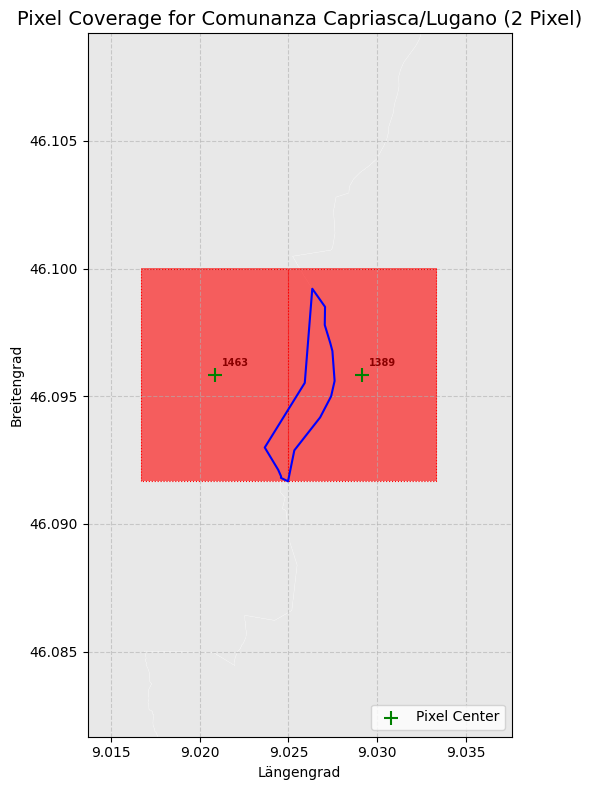

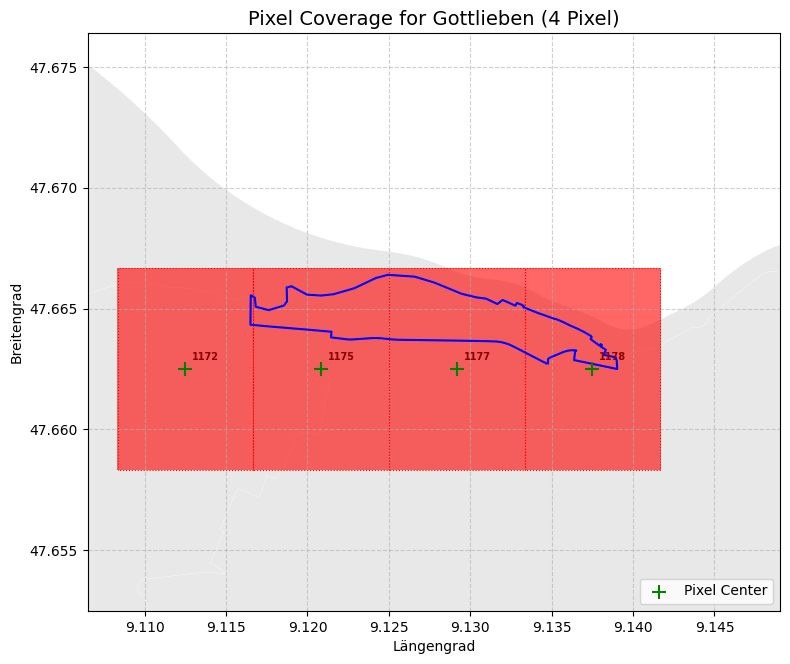

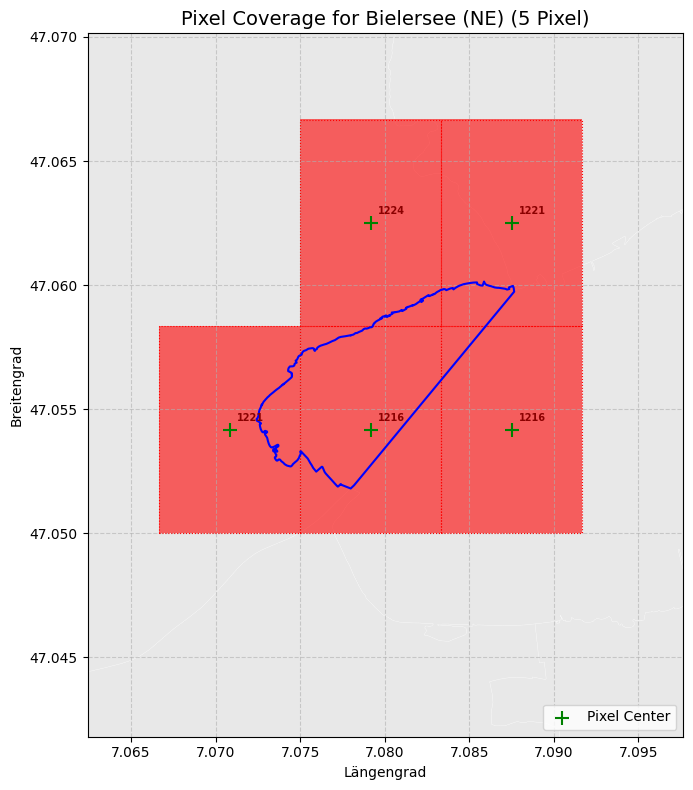

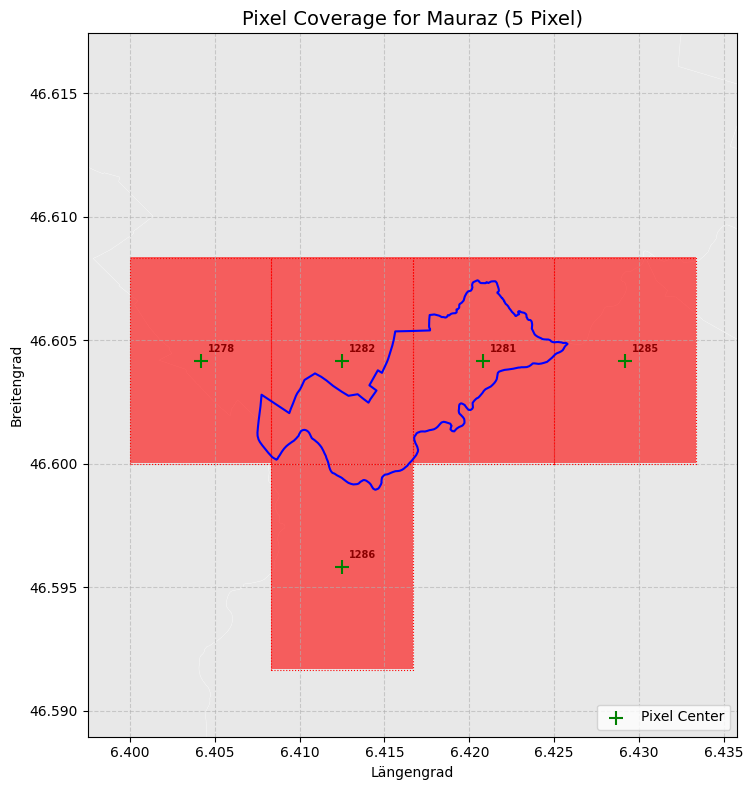

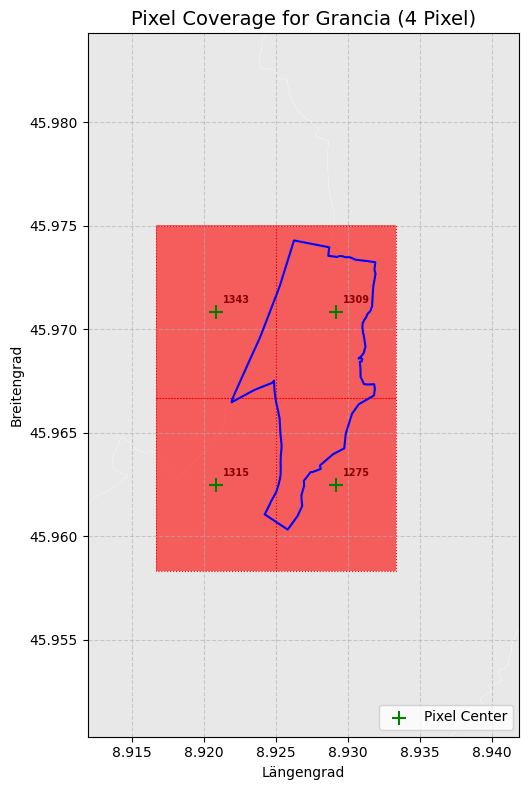

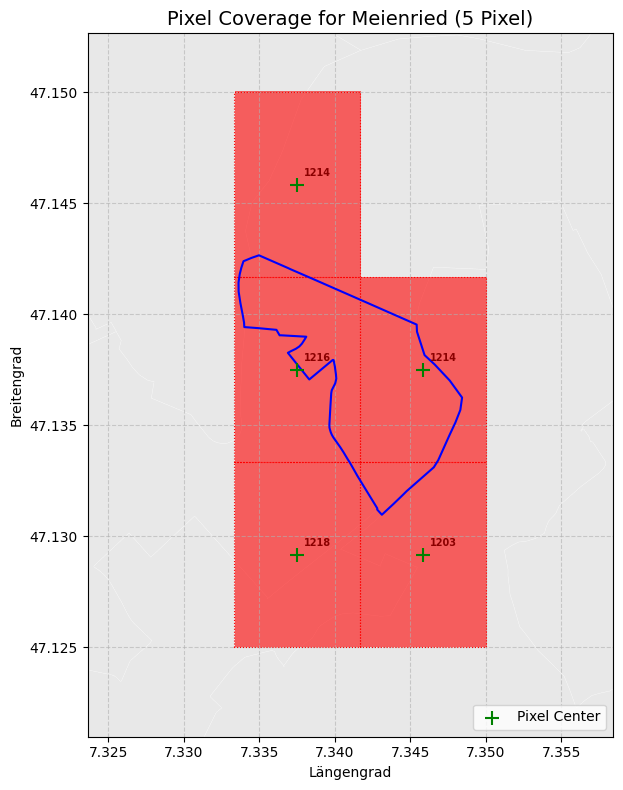

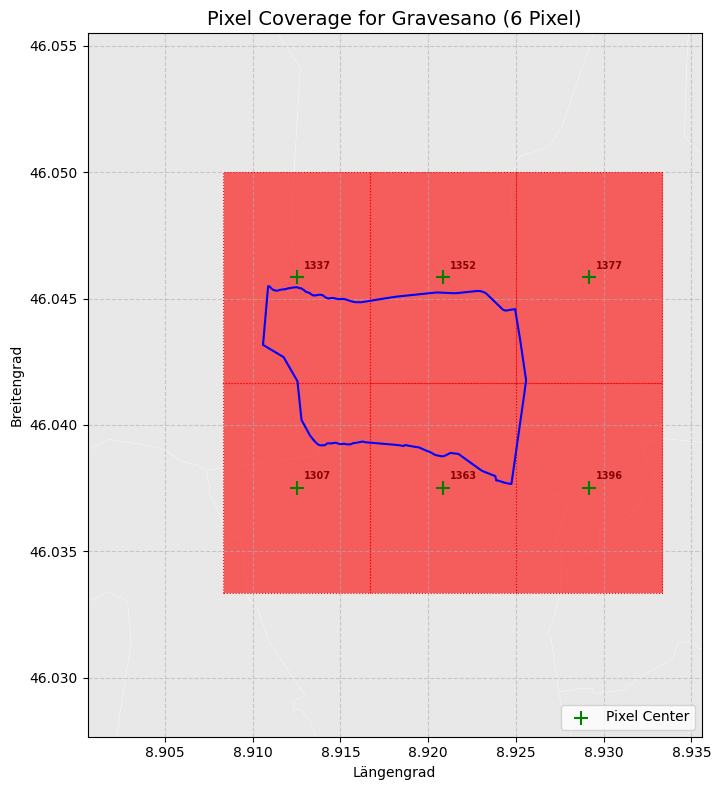

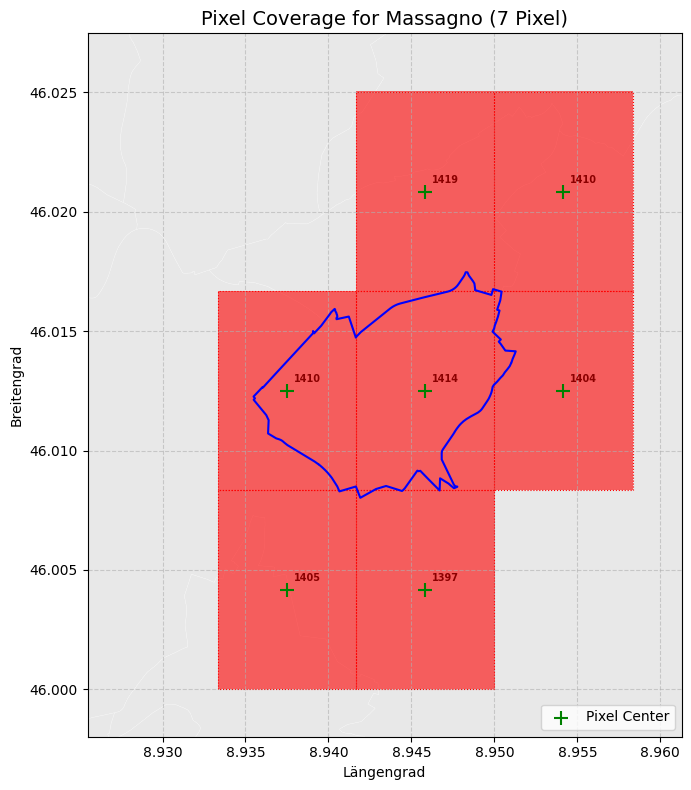

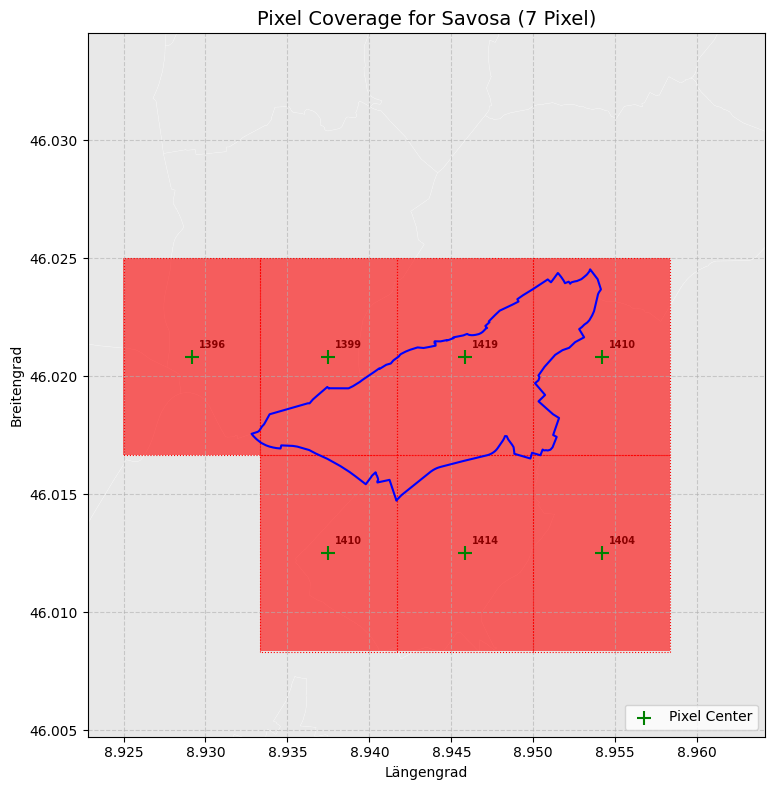

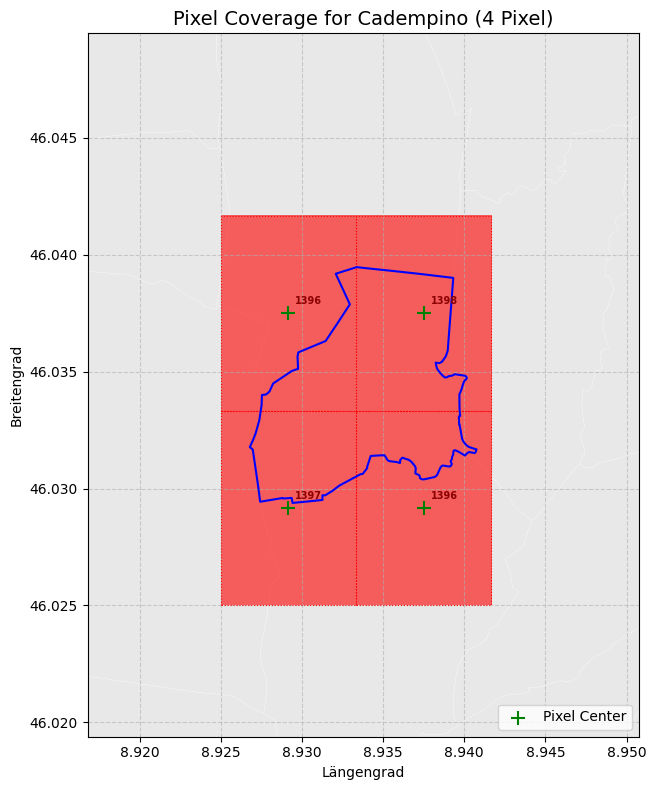

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.plot import show as rasterio_show # Alias, um Konflikte mit plt.show zu vermeiden
import numpy as np
from matplotlib.colors import ListedColormap
from shapely.geometry import box # Import box for pixel geometries

# Öffne das PVOUT-Raster einmal, um seine Eigenschaften (Transformation und Form) zu erhalten
with rasterio.open(PVOUT_PATH) as src:
    raster_transform = src.transform
    raster_shape = src.shape
    raster_crs = src.crs
    # Stelle sicher, dass die vollständigen Rasterdaten geladen werden, da 'data' für Pixelwerte verwendet wird
    full_raster_data = src.read(1) # Annahme: 'data' aus Zelle-07 ist das vollständige Raster

print("Visualisiere die abgedeckten Pixel für jede der 10 kleinsten Gemeinden...")

# Definiere eine benutzerdefinierte Farbkarte: transparent für 0 (kein Pixel), halbtransparentes Rot für 1 (bedecktes Pixel)
colors = [(0, 0, 0, 0), (1, 0, 0, 0.6)] # RGBA: transparent für Hintergrund, halbtransparentes Rot für Pixel
cmap_pixels = ListedColormap(colors)

# Iteriere durch jede der 10 kleinsten Gemeinden
for idx, row in smallest_10_gemeinden.iterrows():
    municipality_name = row['name']
    current_municipality_gdf = gpd.GeoDataFrame([row], crs=gemeinden_wgs84.crs)
    pixel_count = smallest_10_pixel_counts.get(municipality_name, 'N/A')

    # Erstelle eine binäre Maske für die aktuelle Gemeinde
    # Von der Gemeinde bedeckte Pixel erhalten den Wert 1, andere 0
    mask = rasterize(
        [(current_municipality_gdf.geometry.values[0], 1)],
        out_shape=raster_shape,
        transform=raster_transform,
        fill=0,
        all_touched=True
    )

    # Ermittle die (Zeilen-, Spalten-)Indizes der von der Gemeinde bedeckten Pixel
    pixel_rows, pixel_cols = np.where(mask == 1)

    # Konvertiere Pixel-(Zeilen-, Spalten-)Indizes in geografische (Längen-, Breiten-)Koordinaten
    pixel_lons, pixel_lats = rasterio.transform.xy(raster_transform, pixel_rows, pixel_cols)

    # Erstelle Geometrien für Pixelgrenzen und sammle PVOUT-Werte
    pixel_geometries = []
    pixel_pvout_values = []
    for r, c in zip(pixel_rows, pixel_cols):
        # Ermittle die Bounding Box des Pixels
        # raster_transform * (Spalte, Zeile) gibt die obere linke Ecke des Pixels an
        lon_tl, lat_tl = raster_transform * (c, r)
        # raster_transform * (Spalte + 1, Zeile + 1) gibt die untere rechte Ecke des Pixels an
        lon_br, lat_br = raster_transform * (c + 1, r + 1)
        pixel_geometries.append(box(lon_tl, lat_br, lon_br, lat_tl))

        # Ermittle den PVOUT-Wert für dieses Pixel aus den vollständigen Rasterdaten
        pixel_pvout_values.append(full_raster_data[r, c])

    pixel_boundaries_gdf = gpd.GeoDataFrame(geometry=pixel_geometries, crs=raster_crs)

    # Plotten
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plotte alle Gemeinden im Hintergrund als Kontext (hellgrau, niedriger z-Index)
    gemeinden_wgs84.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, alpha=0.5, zorder=0)

    # Plotte die gerasterten Pixel (Maske) über dem Hintergrund (z-Index=1)
    rasterio_show(mask, transform=raster_transform, ax=ax, cmap=cmap_pixels, zorder=1)

    # Plotte die Grenzen der Pixel (z-Index=2, über den Pixeln)
    pixel_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.8, linestyle=':', zorder=2, label='Pixel Boundaries')

    # Plotte die Grenze der aktuellen Gemeinde (z-Index=3, über den Pixelgrenzen)
    current_municipality_gdf.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=1.5, zorder=3, label='Municipality Boundary')

    # Plotte das Zentrum der von der Gemeinde bedeckten Pixel
    ax.scatter(pixel_lons, pixel_lats, color='green', marker='+', s=100, zorder=4, label='Pixel Center')

    # Beschrifte den PVOUT-Mittelwert in jedem Pixel
    for (lon, lat, pv_val) in zip(pixel_lons, pixel_lats, pixel_pvout_values):
        if not np.isnan(pv_val): # Nur beschriften, wenn der PVOUT-Wert kein NaN ist
            ax.annotate(
                f'{pv_val:.0f}',
                xy=(lon, lat),
                xytext=(5, 5),
                textcoords="offset points",
                ha='left', va='bottom',
                color='darkred', fontsize=7, fontweight='bold', zorder=5
            )

    # Setze Titel mit Gemeindename und Pixelanzahl
    ax.set_title(f'Pixel Coverage for {municipality_name} ({pixel_count} Pixel)', fontsize=14)
    ax.set_xlabel('Längengrad')
    ax.set_ylabel('Breitengrad')

    # Zoome auf die Ausdehnung der aktuellen Gemeinde mit einem Puffer
    minx, miny, maxx, maxy = current_municipality_gdf.total_bounds
    buffer_val = 0.01
    ax.set_xlim(minx - buffer_val, maxx + buffer_val)
    ax.set_ylim(miny - buffer_val, maxy + buffer_val)

    plt.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

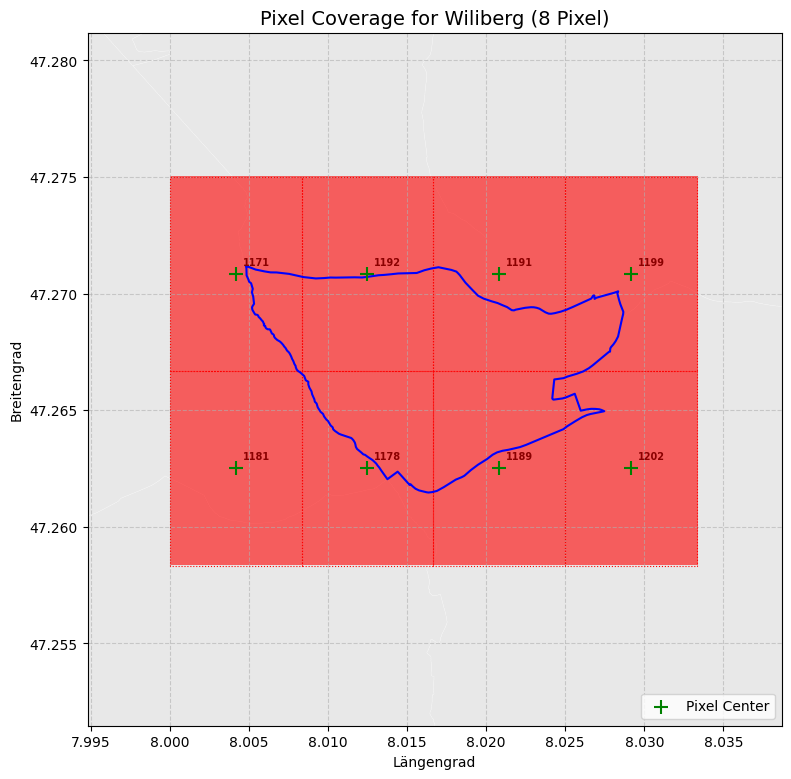

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.plot import show as rasterio_show
from matplotlib.colors import ListedColormap
from shapely.geometry import box

# Konfiguration
TARGET_MUNICIPALITY = 'Wiliberg'
BUFFER = 0.01

# Raster laden
with rasterio.open(PVOUT_PATH) as src:
    raster_transform = src.transform
    raster_crs = src.crs
    raster_data = src.read(1)

# Gemeinde auswählen
municipality_gdf = gemeinden_wgs84[gemeinden_wgs84['name'] == TARGET_MUNICIPALITY]
pixel_count = pixel_counts.get(TARGET_MUNICIPALITY, 'N/A')

# Pixel der Gemeinde ermitteln
mask = rasterize(
    [(municipality_gdf.geometry.values[0], 1)],
    out_shape=raster_data.shape,
    transform=raster_transform,
    fill=0,
    all_touched=True,
)
pixel_rows, pixel_cols = np.where(mask)
pixel_lons, pixel_lats = rasterio.transform.xy(raster_transform, pixel_rows, pixel_cols)
pixel_values = raster_data[pixel_rows, pixel_cols]

# Pixel-Polygone für die Umrisse erzeugen
pixel_boundaries = gpd.GeoDataFrame(
    geometry=[
        box(*(raster_transform * (c, r + 1)), *(raster_transform * (c + 1, r)))
        for r, c in zip(pixel_rows, pixel_cols)
    ],
    crs=raster_crs,
)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
cmap_pixels = ListedColormap([(0, 0, 0, 0), (1, 0, 0, 0.6)])

gemeinden_wgs84.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, alpha=0.5, zorder=0)
rasterio_show(mask, transform=raster_transform, ax=ax, cmap=cmap_pixels, zorder=1)
pixel_boundaries.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.8, linestyle=':', zorder=2, label='Pixel Boundaries')
municipality_gdf.plot(ax=ax, facecolor='none', edgecolor='blue', linewidth=1.5, zorder=3, label='Municipality Boundary')
ax.scatter(pixel_lons, pixel_lats, color='green', marker='+', s=100, zorder=4, label='Pixel Center')

# PVOUT-Werte beschriften
for lon, lat, val in zip(pixel_lons, pixel_lats, pixel_values):
    if not np.isnan(val):
        ax.annotate(
            f'{val:.0f}', xy=(lon, lat), xytext=(5, 5),
            textcoords='offset points', ha='left', va='bottom',
            color='darkred', fontsize=7, fontweight='bold', zorder=5,
        )

# Auf Gemeinde zoomen
minx, miny, maxx, maxy = municipality_gdf.total_bounds
ax.set_xlim(minx - BUFFER, maxx + BUFFER)
ax.set_ylim(miny - BUFFER, maxy + BUFFER)

ax.set_title(f'Pixel Coverage for {TARGET_MUNICIPALITY} ({pixel_count} Pixel)', fontsize=14)
ax.set_xlabel('Längengrad')
ax.set_ylabel('Breitengrad')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Datenbereinigung pvout_mean der vier Gemeinden

In [ ]:
import geopandas as gpd
from rasterstats import zonal_stats
import pandas as pd
import numpy as np
import rasterio

# Annahme: gemeinden_wgs84_with_stats, PVOUT_PATH und KANTON_NAME sind bereits aus vorherigen Zellen definiert.

print("Beginne mit der Berechnung des PVOUT-Mittelwerts für Gemeinden mit fehlenden Werten (pvout_mean = NaN)...")

# Filtere Gemeinden mit NaN-pvout_mean, die imputiert werden müssen
# Erstelle eine Kopie, um SettingWithCopyWarning zu vermeiden
municipalities_to_impute = gemeinden_wgs84_with_stats[gemeinden_wgs84_with_stats['pvout_mean'].isna()].copy()

if not municipalities_to_impute.empty:
    print(f"Es wurden {len(municipalities_to_impute)} Gemeinden mit fehlenden PVOUT-Werten gefunden.")
    print("Berechne den mittleren PVOUT und die Anzahl der abgedeckten Pixel für diese Gemeinden...")

    # Der 'with rasterio.open(PVOUT_PATH) as src:' Block wurde hier entfernt
    # und PVOUT_PATH wird direkt an zonal_stats übergeben.
    # zonal_stats übernimmt das interne Öffnen und Schliessen der Rasterdatei.

    # Bereite eine Liste vor, um Ergebnisse für diese spezifischen Gemeinden zu speichern
    imputation_results = []
    original_indices = []

    for idx, row in municipalities_to_impute.iterrows():
        # Berechne zonale Statistiken für die Geometrie der aktuellen Gemeinde
        # Schliesse 'mean' und 'count' mit all_touched=True ein
        current_stats = zonal_stats(
            [row.geometry], # Geometrie der aktuellen Gemeinde
            PVOUT_PATH,     # Übergibt den Pfad-String anstelle des geöffneten 'src'-Objekts
            stats=['mean', 'count'], # Fordere sowohl Mittelwert als auch Pixelanzahl an
            nodata=-9999,
            all_touched=True
        )

        # current_stats ist eine Liste mit einem Wörterbuch
        result_dict = current_stats[0]
        imputation_results.append(result_dict)
        original_indices.append(idx)

    # Erstelle ein DataFrame aus den Imputationsergebnissen
    imputation_df = pd.DataFrame(imputation_results, index=original_indices)

    print("\nBerechnete PVOUT-Mittelwerte und Pixel-Counts für die ehemals fehlenden Gemeinden:")
    display(imputation_df) # Display the calculated imputation_df

    # Aktualisiere die Spalte 'pvout_mean' im Haupt-GeoDataFrame
    # Nur aktualisieren, wenn ein gültiger Mittelwert gefunden wurde (nicht None und nicht NaN)
    for idx, row_imputed in imputation_df.iterrows():
        new_mean = row_imputed['mean']
        pixel_count_for_imputed = row_imputed['count']

        if new_mean is not None and not np.isnan(new_mean):
            gemeinden_wgs84_with_stats.loc[idx, 'pvout_mean'] = new_mean
            print(f"- {gemeinden_wgs84_with_stats.loc[idx, 'name']}: PVOUT-Mittelwert auf {new_mean:.0f} (aus {pixel_count_for_imputed} Pixeln) aktualisiert.")
        else:
            print(f"- {gemeinden_wgs84_with_stats.loc[idx, 'name']}: Konnte keinen gültigen PVOUT-Mittelwert finden, auch mit 'all_touched=True' ({pixel_count_for_imputed} Pixel abgedeckt). PVOUT-Mittelwert bleibt NaN.")


    print("\nPVOUT-Mittelwerte für ehemals fehlende Gemeinden wurden aktualisiert.")

    # Überprüfe die Änderungen für die ursprünglich fehlenden Gemeinden
    updated_missing_pvout_gemeinden = gemeinden_wgs84_with_stats[gemeinden_wgs84_with_stats['bfs_nummer'].isin(municipalities_to_impute['bfs_nummer'])]

    print("\nDetails der Gemeinden, für die PVOUT-Werte aktualisiert wurden:")
    display(updated_missing_pvout_gemeinden[['bfs_nummer', 'name', 'kanton_name', 'area_sqkm', 'pvout_mean']])

    remaining_nan_count = updated_missing_pvout_gemeinden['pvout_mean'].isna().sum()
    if remaining_nan_count > 0:
        print(f"\nHinweis: {remaining_nan_count} Gemeinden haben immer noch NaN für pvout_mean, selbst mit 'all_touched=True' und 'count'.")
        display(updated_missing_pvout_gemeinden[updated_missing_pvout_gemeinden['pvout_mean'].isna()][['bfs_nummer', 'name', 'kanton_name', 'area_sqkm', 'pvout_mean']])
    else:
        print("\nAlle ehemals fehlenden PVOUT-Werte wurden erfolgreich imputiert.")

else:
    print("Keine Gemeinden mit fehlenden PVOUT-Werten (pvout_mean = NaN) gefunden, die imputiert werden müssten.")


# Es ist gute Praxis, 'pvout_gemeinden' zu aktualisieren, um diese Änderungen widerzuspiegeln
# da es in nachfolgenden Zellen für Analyse und Speichern verwendet wird.
pvout_gemeinden = gemeinden_wgs84_with_stats[['bfs_nummer', 'name', 'kanton_name', 'pvout_mean']].copy()
pvout_gemeinden.columns = ['gemeinde_nr', 'gemeinde_name', 'kanton_name', 'pvout_kwh_kwp_year']

print("\n'pvout_gemeinden' DataFrame wurde mit den imputierten Werten aktualisiert und ist bereit für die nächsten Schritte.")

Beginne mit der Berechnung des PVOUT-Mittelwerts für Gemeinden mit fehlenden Werten (pvout_mean = NaN)...
Es wurden 4 Gemeinden mit fehlenden PVOUT-Werten gefunden.
Berechne den mittleren PVOUT und die Anzahl der abgedeckten Pixel für diese Gemeinden...

Berechnete PVOUT-Mittelwerte und Pixel-Counts für die ehemals fehlenden Gemeinden:


,mean,count
333,1175.374512,4
1008,1188.021484,8
1275,1355.442790,6
1442,1426.118530,2


- Gottlieben: PVOUT-Mittelwert auf 1175 (aus 4.0 Pixeln) aktualisiert.
- Wiliberg: PVOUT-Mittelwert auf 1188 (aus 8.0 Pixeln) aktualisiert.
- Gravesano: PVOUT-Mittelwert auf 1355 (aus 6.0 Pixeln) aktualisiert.
- Comunanza Capriasca/Lugano: PVOUT-Mittelwert auf 1426 (aus 2.0 Pixeln) aktualisiert.

PVOUT-Mittelwerte für ehemals fehlende Gemeinden wurden aktualisiert.

Details der Gemeinden, für die PVOUT-Werte aktualisiert wurden:


,bfs_nummer,name,kanton_name,area_sqkm,pvout_mean
333,4651,Gottlieben,Thurgau,0.324289,1175.374512
1008,4288,Wiliberg,Aargau,1.170455,1188.021484
1275,5187,Gravesano,Ticino,0.711523,1355.442790
1442,5394,Comunanza Capriasca/Lugano,Ticino,0.087127,1426.118530



Alle ehemals fehlenden PVOUT-Werte wurden erfolgreich imputiert.

'pvout_gemeinden' DataFrame wurde mit den imputierten Werten aktualisiert und ist bereit für die nächsten Schritte.


##7 Ergebnis-Tabelle erstellen

**Ziel:** Die berechneten PVOUT-Werte mit den Gemeindeinformationen in eine übersichtliche Tabelle zusammenführen.

**Vorgehen:** PVOUT-Mittelwert als neue Spalte anfügen, nicht benötigte Spalten entfernen, Kantonsname hinzufügen, Zeilen ohne Wert entfernen.

**Was der Code macht – im Detail:**

**Welche Spalten gibt es im GPKG, und warum werden die meisten nicht verwendet?**  
Der Layer `tlm_hoheitsgebiet` enthält 23 Spalten, darunter: `uuid`, `datum_aenderung`, `datum_erstellung`, `erstellung_jahr`, `erstellung_monat`, `grund_aenderung`, `herkunft`, `revision_jahr`, `revision_qualitaet`, `objektart`, `bezirksnummer`, `gem_flaeche`, `see_flaeche`, `icc`, `shn`, `einwohnerzahl`, `hist_nr` u.v.m.  
Diese Verwaltungs- und Historisierungsfelder brauchen wir für die Analyse nicht. Wir behalten nur 4 inhaltlich relevante Spalten: `bfs_nummer`, `name`, `kantonsnummer` und den berechneten `pvout_kwh_kwp_year`.

**Kantonsname statt Kantonnummer:**  
Das GPKG enthält nur die Kantonnummer (1–26), keinen lesbaren Kantonsnamen. Deshalb wird eine Zuordnungstabelle (`KANTON_NAME`) verwendet, um die Nummer in den deutschen Kantonsnamen umzuwandeln.

**Warum gibt es Zeilen ohne PVOUT-Wert?**  
`zonal_stats()` berechnet den Mittelwert aller Pixel *innerhalb* eines Gemeindepolygons. Bei sehr kleinen Gemeinden (Fläche kleiner als ein Pixel = < 1 km²) liegt kein einziger Pixelmittelpunkt im Polygon. Das Ergebnis für diese Gemeinden ist `None`. `dropna()` entfernt sie. Der Vergleich vor/nach zeigt wie viele das betrifft.

In [ ]:
import pandas as pd

gemeinden_wgs84['pvout_kwh_kwp_year'] = [s['mean'] for s in stats]
gemeinden_wgs84['kanton_name'] = gemeinden_wgs84['kantonsnummer'].map(KANTON_NAME)

pvout_gemeinden = gemeinden_wgs84[['bfs_nummer', 'name', 'kanton_name', 'pvout_kwh_kwp_year']].copy()
pvout_gemeinden.columns = ['gemeinde_nr', 'gemeinde_name', 'kanton_name', 'pvout_kwh_kwp_year']

vor_dropna = len(pvout_gemeinden)
pvout_gemeinden = pvout_gemeinden.dropna(subset=['pvout_kwh_kwp_year'])
nach_dropna = len(pvout_gemeinden)

pv_min  = pvout_gemeinden['pvout_kwh_kwp_year'].min()
pv_max  = pvout_gemeinden['pvout_kwh_kwp_year'].max()
pv_mean = pvout_gemeinden['pvout_kwh_kwp_year'].mean()

print(f'Gemeinden total      : {vor_dropna}')
print(f'Ohne PVOUT-Wert      : {vor_dropna - nach_dropna}  (Polygon kleiner als 1 Pixel)')
print(f'Gemeinden mit Daten  : {nach_dropna}')
print(f'PVOUT-Bereich        : {pv_min:.0f} – {pv_max:.0f} kWh/kWp/Jahr')
print(f'Schweizer Mittelwert : {pv_mean:.0f} kWh/kWp/Jahr')
pvout_gemeinden.head(5)

Gemeinden total      : 2136
Ohne PVOUT-Wert      : 4  (Polygon kleiner als 1 Pixel)
Gemeinden mit Daten  : 2132
PVOUT-Bereich        : 885 – 1485 kWh/kWp/Jahr
Schweizer Mittelwert : 1220 kWh/kWp/Jahr


,gemeinde_nr,gemeinde_name,kanton_name,pvout_kwh_kwp_year
0,131,Adliswil,Zürich,1155.791391
1,3714,Rheinwald,Graubünden,1273.649336
2,5722,Grens,Vaud,1292.010905
3,6730,Val Terbi,Jura,1131.424248
4,4123,Windisch,Aargau,1164.307422


##8 Rangliste prüfen (Qualitätskontrolle 4)

**Ziel:** Top- und Bottom-Gemeinden auf Plausibilität prüfen.

**Erwartung:** Walliser und Tessiner Gemeinden ganz oben, nördliche oder schattige Gemeinden ganz unten.

**Was der Code macht:**
- `nlargest(10, ...)` sortiert die Tabelle absteigend und gibt die 10 höchsten Werte zurück
- `nsmallest(10, ...)` gibt die 10 niedrigsten Werte zurück
- So kann man sofort sehen, ob die Daten geografisch sinnvoll sind

In [ ]:
print('=== Top 10 – höchster PV-Ertrag ===')
top10 = pvout_gemeinden.nlargest(10, 'pvout_kwh_kwp_year')[['gemeinde_name', 'pvout_kwh_kwp_year']]
print(top10.to_string(index=False))

print()
print('=== Bottom 10 – niedrigster PV-Ertrag ===')
bot10 = pvout_gemeinden.nsmallest(10, 'pvout_kwh_kwp_year')[['gemeinde_name', 'pvout_kwh_kwp_year']]
print(bot10.to_string(index=False))

print()
print('Erwartung: Top = Wallis / Tessin / Graubünden (Südhänge)')
print('           Bottom = nördliche Täler / alpine Schattenlage')

=== Top 10 – höchster PV-Ertrag ===
       gemeinde_name  pvout_kwh_kwp_year
      Guttet-Feschel         1485.263114
       Crans-Montana         1476.687500
                Lens         1473.579219
           Grimisuat         1469.887695
               Arbaz         1469.589214
               Varen         1465.632102
          Ausserberg         1461.949531
       Noble-Contrée         1435.797656
            Orselina         1430.684082
Brione sopra Minusio         1426.788411

=== Bottom 10 – niedrigster PV-Ertrag ===
 gemeinde_name  pvout_kwh_kwp_year
      Därligen          884.726888
      Emmetten          957.074139
       Bönigen          958.640700
    Wilderswil          960.059482
     Rongellen          973.573975
     Leissigen          980.889706
Hergiswil (NW)          994.655762
     Iseltwald         1000.370355
    Schattdorf         1001.553341
  Seedorf (UR)         1002.156597

Erwartung: Top = Wallis / Tessin / Graubünden (Südhänge)
           Bottom = nördlic

## 10 Datenqualität

##9 Choropleth-Karte – PVOUT pro Gemeinde

**Ziel:** Alle Gemeinden auf einer Karte anzeigen, eingefärbt nach ihrem mittleren PVOUT-Wert.

**Vorgehen:** Jedes Gemeinde-Polygon wird entsprechend dem berechneten Mittelwert eingefärbt.

**Was der Code macht:**
- `geopandas.plot(column='pvout_kwh_kwp_year', cmap='YlOrRd')` zeichnet die Choropleth-Karte
- Grau = Gemeinden ohne berechneten PVOUT-Wert (sehr klein oder am Rand)
- Die Legende rechts erklärt die Farbskala in kWh/kWp/Jahr
- Diese Karte ist hochauflösender als die Pixel-Karte aus Schritt 4, da hier Gemeindepolygone verwendet werden

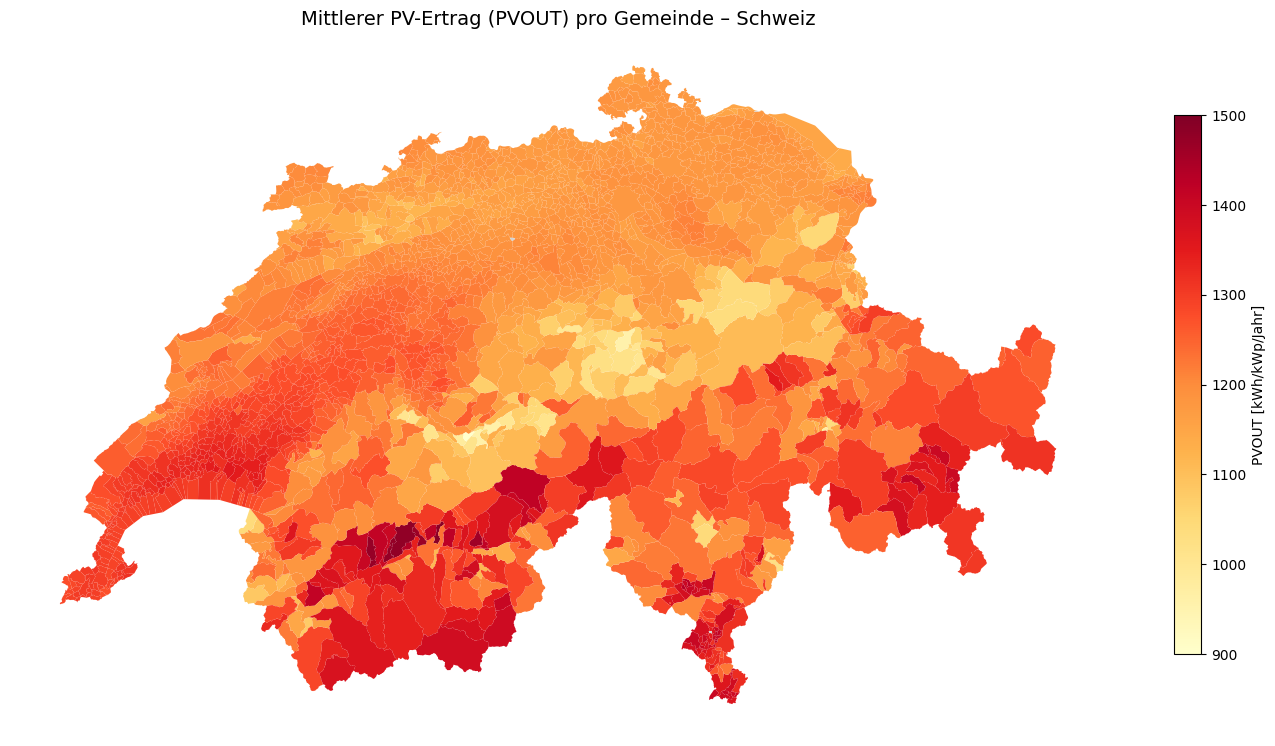

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
gemeinden_wgs84.plot(
    column='pvout_kwh_kwp_year',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'PVOUT [kWh/kWp/Jahr]', 'shrink': 0.7},
    ax=ax,
    missing_kwds={'color': 'lightgrey', 'label': 'keine Daten'},
    vmin=900,
    vmax=1500
)
ax.set_title('Mittlerer PV-Ertrag (PVOUT) pro Gemeinde – Schweiz', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

### Überprüfung auf NaN-Werte

In [ ]:
nan_counts_per_column = pvout_gemeinden.isna().sum()
total_nan_count = nan_counts_per_column.sum()

print("Anzahl der NaN-Werte pro Spalte:")
print(nan_counts_per_column)
print(f"\nTotal: {total_nan_count}")

Anzahl der NaN-Werte pro Spalte:
gemeinde_nr            0
gemeinde_name          0
kanton_name           13
pvout_kwh_kwp_year     0
dtype: int64

Total: 13


### Überprüfung auf Nullwerte (0 oder 0.0)

In [ ]:
zero_values_found_overall = False # Gesamtergebnis für das Auffinden von Nullwerten

print("Überprüfe das DataFrame auf 0.0 oder 0 Werte:")
for column in pvout_gemeinden.columns:
    # Nur numerische Spalten prüfen
    if pd.api.types.is_numeric_dtype(pvout_gemeinden[column]):
        zeros_count = pvout_gemeinden[pvout_gemeinden[column] == 0].shape[0]
        if zeros_count > 0:
            zero_values_found_overall = True
            print(f"  Spalte '{column}': {zeros_count} Werte sind 0 oder 0.0")

if not zero_values_found_overall:
    print("  Es wurden keine Werte von 0.0 oder 0 in den numerischen Spalten des 'pvout_gemeinden' DataFrame gefunden.")

Überprüfe das DataFrame auf 0.0 oder 0 Werte:
  Es wurden keine Werte von 0.0 oder 0 in den numerischen Spalten des 'pvout_gemeinden' DataFrame gefunden.


### Spalte kanton_name

Die 13 Gemeinden ohne Kantonszuordnung (NaN) umfassen die 11 Gemeinden Liechtensteins (7001–7011) sowie zwei ausländische Exklaven auf Schweizer Gebiet: 7101 Büsingen am Hochrhein (DE) und 7301 Campione d'Italia (IT).

In [ ]:
nan_found_overall = False # Gesamtergebnis für das Auffinden von NaN-Werten
for column in pvout_gemeinden.columns:
    nan_rows = pvout_gemeinden[pvout_gemeinden[column].isna()]
    if not nan_rows.empty:
        nan_found_overall = True
        print(nan_rows.to_string(index=False))

if not nan_found_overall:
    print("Es wurden keine NaN-Werte gefunden.")

 gemeinde_nr         gemeinde_name kanton_name  pvout_kwh_kwp_year
        7004           Triesenberg         NaN         1173.846301
        7011          Schellenberg         NaN         1201.515904
        7010               Ruggell         NaN         1224.318004
        7008                Mauren         NaN         1149.807059
        7002               Triesen         NaN         1069.406250
        7005                Schaan         NaN         1143.888313
        7001                 Vaduz         NaN         1141.758440
        7003               Balzers         NaN         1128.611084
        7101 Büsingen am Hochrhein         NaN         1181.443209
        7301     Campione d'Italia         NaN         1273.699805
        7007                Eschen         NaN         1165.593859
        7009               Gamprin         NaN         1168.325195
        7006               Planken         NaN         1074.897638


### Gemeinde mit NaN-Werten entfernen

Die Liechtensteiner Gemeinden sind in den Stromdaten (02_Stromdaten_Preparation.ipynb) nicht enthalten und werden daher bereits hier entfernt.

In [ ]:
print(f"Anzahl Gemeinden vor Entfernung von NaN: {len(pvout_gemeinden)}")
pvout_gemeinden = pvout_gemeinden.dropna(subset=['kanton_name'])
print(f"Anzahl Gemeinden nach Entfernung von NaN: {len(pvout_gemeinden)}")

if pvout_gemeinden['kanton_name'].isna().any():
    print("WARNUNG: Es sind immer noch NaN-Werte in 'kanton_name' vorhanden, obwohl diese entfernt werden sollten.")
    print("Betroffene Zeilen:")
    print(pvout_gemeinden[pvout_gemeinden['kanton_name'].isna()].to_string(index=False))
else:
    print("Bestätigung: Alle NaN-Werte in der Spalte 'kanton_name' wurden erfolgreich entfernt.")

Anzahl Gemeinden vor Entfernung von NaN: 2132
Anzahl Gemeinden nach Entfernung von NaN: 2119
Bestätigung: Alle NaN-Werte in der Spalte 'kanton_name' wurden erfolgreich entfernt.


##11 Ergebnis als CSV speichern

**Ziel:** Die berechneten PVOUT-Werte für alle Gemeinden speichern, damit Notebook 3 (Auswertung) sie direkt laden kann – ohne die lange Berechnung nochmals durchführen zu müssen.

**Was der Code macht:**
- Die CSV enthält 4 Spalten: `gemeinde_nr`, `gemeinde_name`, `kanton_name`, `pvout_kwh_kwp_year`
- `index=False` verhindert, dass pandas eine zusätzliche Zeilennummer-Spalte hinzufügt

In [ ]:
import os
from google.colab import files

output_path = 'pvout_gemeinden.csv'

# Eine Sitzungs-Flag initialisieren. Diese wird zurückgesetzt, wenn die Runtime neu gestartet wird.
if '_downloaded_pvout_csv_once' not in globals():
    _downloaded_pvout_csv_once = False

pvout_gemeinden.to_csv(output_path, index=False)
print(f'✓ Gespeichert : {output_path}')
print(f'  {len(pvout_gemeinden)} Zeilen | Spalten: {list(pvout_gemeinden.columns)}')

# Nur herunterladen, wenn in dieser Sitzung noch nicht geschehen
if not _downloaded_pvout_csv_once:
    if os.path.exists(output_path):
        files.download(output_path)
        print(f'Datei \'{output_path}\' wurde heruntergeladen.')
        _downloaded_pvout_csv_once = True
    else:
        print(f'Warnung: Datei \'{output_path}\' nicht gefunden, obwohl sie gerade gespeichert werden sollte.')
elif _downloaded_pvout_csv_once:
    print(f'Datei \'{output_path}\' wurde bereits in dieser Sitzung heruntergeladen. Kein erneuter Download.')


✓ Gespeichert : pvout_gemeinden.csv
  2132 Zeilen | Spalten: ['gemeinde_nr', 'gemeinde_name', 'kanton_name', 'pvout_kwh_kwp_year']
Datei 'pvout_gemeinden.csv' wurde bereits in dieser Sitzung heruntergeladen. Kein erneuter Download.


##12 Adresse eingeben

**Ziel:** Eine konkrete Schweizer Adresse angeben, für die der PVOUT-Wert abgefragt werden soll.

**Vorgehen:** Einfach die Adresse in der Variable `ADRESSE` anpassen und danach Schritt 13 ausführen.

**Tipps:**
- Am besten immer Ort und «Schweiz» anhängen: `Hauptstrasse 1, Bern, Schweiz`
- Zum Vergleich lohnt sich eine sonnige Bergadresse, z.B. `Täsch, Schweiz` (Mattertal, Südexposition)
- Im flachen Mittelland sind Nachbarpixel ähnlich – das ist physikalisch korrekt, kein Fehler

In [ ]:
# <- HIER ADRESSE ANPASSEN (dann Schritt 13 ausführen)
ADRESSE = 'Bundesplatz 3, Bern, Schweiz'

# Testadressen zum Vergleich:
# ADRESSE = 'Lugano, Schweiz'         # sehr sonnig, Tessin
# ADRESSE = 'Täsch, Schweiz'          # sonnig, Südexposition Mattertal
# ADRESSE = 'Randa, Schweiz'          # weniger sonnig, Schattental
# ADRESSE = 'Zürich, Schweiz'         # typisches Mittelland

##13 PVOUT-Wert und Gemeinde für die eingegebene Adresse abfragen

**Ziel:** Für die oben eingegebene Adresse den PVOUT-Pixelwert und die zugehörige Gemeinde ausgeben.

**Vorgehen:** Drei Teilschritte:
1. **Adresse → Koordinaten** – swisstopo API als Hauptquelle (kennt alle offiziellen Schweizer Adressen), Nominatim als Fallback
2. **Koordinaten → PVOUT-Pixelwert** – rasterio liest den nächsten Pixel aus PVOUT.tif
3. **Koordinaten → Gemeinde** – Spatial Join: der Punkt wird einem Gemeinde-Polygon zugeordnet

**Hinweis zur Auflösung:**  
Die Datei hat eine Auflösung von 0.9 km × 0.9 km pro Pixel. Zwei Adressen im gleichen Quartier können denselben Pixelwert haben – das ist ein Auflösungseffekt der Datenquelle, kein Fehler. Im Mittelland sind auch Nachbarpixel ähnlich (kaum Topografie). Grössere Unterschiede zeigen sich in Bergregionen: Nord- vs. Südhang können 30–40 % auseinanderliegen.

In [ ]:
import requests
from geopy.geocoders import Nominatim
from shapely.geometry import Point

def geocodiere_adresse(adresse):
    # Primär: swisstopo API (kennt alle offiziellen CH-Adressen aus dem Gebäuderegister)
    try:
        url = 'https://api3.geo.admin.ch/rest/services/api/SearchServer'
        params = {'type': 'locations', 'searchText': adresse, 'limit': 1, 'sr': '4326'}
        r = requests.get(url, params=params, timeout=10)
        results = r.json().get('results', [])
        if results:
            attrs = results[0]['attrs']
            return attrs['lat'], attrs['lon'], attrs.get('label', adresse), 'swisstopo'
    except Exception:
        pass
    # Fallback: Nominatim / OpenStreetMap
    try:
        gc = Nominatim(user_agent='bina-pv-projekt')
        ort = gc.geocode(adresse)
        if ort:
            return ort.latitude, ort.longitude, ort.address, 'Nominatim'
    except Exception:
        pass
    return None, None, None, None


# 1. Adresse geocodieren
lat, lon, gefunden, quelle = geocodiere_adresse(ADRESSE)

if not lat:
    print(f'Adresse nicht gefunden: {ADRESSE}')
    print('Tipp: Ort und "Schweiz" anfügen, z.B. "Hauptstrasse 1, Bern, Schweiz"')
else:
    print(f'Geocoding ({quelle}): {gefunden}')
    print(f'Koordinaten: {lat:.5f}°N, {lon:.5f}°E')

    # 2. PVOUT-Pixelwert lesen
    with rasterio.open(PVOUT_PATH) as src:
        r, c = rowcol(src.transform, lon, lat)
        pvout_wert = float(src.read(1)[r, c])
    print()
    print(f'PVOUT: {pvout_wert:.0f} kWh/kWp/Jahr')

    # 3. Gemeinde via Spatial Join ermitteln
    punkt = gpd.GeoDataFrame(geometry=[Point(lon, lat)], crs='EPSG:4326')
    treffer = gpd.sjoin(punkt, gemeinden_wgs84[['bfs_nummer', 'name', 'geometry']], how='left', predicate='within')
    if len(treffer) > 0 and not treffer['name'].isna().all():
        gname = treffer['name'].values[0]
        gnr   = int(treffer['bfs_nummer'].values[0])
        print(f'Gemeinde: {gname} (BFS-Nr: {gnr})')
    else:
        print('Gemeinde: nicht ermittelbar')

    print()
    print('=' * 45)
    print(f'Adresse : {ADRESSE}')
    print(f'PVOUT   : {pvout_wert:.0f} kWh/kWp/Jahr')
    print('=' * 45)

Geocoding (swisstopo): Bundesplatz 3 <b>3011 Bern</b>
Koordinaten: 46.94677°N, 7.44419°E

PVOUT: 1254 kWh/kWp/Jahr
Gemeinde: Bern (BFS-Nr: 351)

Adresse : Bundesplatz 3, Bern, Schweiz
PVOUT   : 1254 kWh/kWp/Jahr
